<a href="https://colab.research.google.com/github/domysolano/Multiple-linear-regression/blob/main/PracticaRegresionLinealMultiple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 🤖 **Maestría en Inteligencia Artificial y Analítica de Datos** 🤖

Asignatura: *Programación para Analítica Descriptiva y Predictiva*

* Semestre: Enero-Junio 2026
* Profesor: Dr. Vicente García Jiménez
* Alumno: Ricardo Solano Monje
* Matrícula: 266221
* Unidad 3.
* Práctica 01-Semana 11: Regresión Lineal Múltiple.
* Dataset: `advertising.csv`
* Objetivo de la práctica: Al finalizar esta práctica, el estudiante será capaz de **aplicar regresión lineal múltiple utilizando Scikit-Learn para modelar la relación entre varias variables independientes y una variable dependiente**, verificar los supuestos del modelo, interpretar los coeficientes, analizar la correlación entre predictores y evaluar el rendimiento del modelo utilizando métricas como el MSE, RMSE y R².
* Realizado por: Ricardo Solano Monje

In [36]:
import pandas as pd
from IPython.display import display, Markdown
from datetime import date
from datetime import datetime
from zoneinfo import ZoneInfo

today = date.today()
time_zone = ZoneInfo('America/Ciudad_Juarez')
current_time_aware = datetime.now(time_zone)

display(Markdown(f"### Current time in Cd. Juárez, Chih.: {current_time_aware.strftime('%H:%M:%S')}"))
formatted_date = datetime.now(time_zone).strftime("%B %d, %Y")
display(Markdown(f"### Today's date: {formatted_date}"))

### Current time in Cd. Juárez, Chih.: 21:50:49

### Today's date: April 26, 2026

# 📋 Table of Contents

✅ Task 1: Carga de datos y bibliotecas

✅ Task 2: Análisis exploratorio de los datos

✅ Task 3: Multicolinealidad

✅ Task 4: Evaluación del Modelo

✅ Task 5: Construcción del Modelo (sin Multicolinealidad), Evaluación

✅ Task 6: Construcción del Modelo (sin variables que no muestran una relación lineal), Evaluación

✅ Task 7: Conclusiones

🧩 Appendix
- Reference Patterns for Residuals vs Predicted Plot
- Reference patterns for Q-Q plots: What They Tell You About Your Data

> *The appendix contains necessarily technical information for the comprehension of the theoretical questions. Some of them appear as hints, rised as curiosity.*
>
> *Even though the appendix was mean as a complementary textual theory, some code inside them has been copied as an extra cell then run to realise the ideas it gathers.*

### Datos
Trabajarás con el archivo `advertising.csv`, que contiene información sobre el gasto publicitario en diferentes medios y las ventas obtenidas:

-`TV`: inversión en publicidad televisiva.

-`Radio`: inversión en publicidad en radio.

-`Newspaper`: inversión en publicidad en periódicos.

`Sales`: ventas del producto (variable dependiente).

## Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `advertising.csv`.
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente las variables.

In [37]:
# Tu código aquí
# advertising_regression.py

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def load_data(filepath):
    """Load the advertising dataset."""
    df = pd.read_csv(filepath)
    return df

def display_head(df):
    """Display first few rows."""
    print("First 5 rows of the dataset:")
    print(df.head())

def describe_data(df):
    """Display statistical description."""
    print("\nStatistical description of variables:")
    print(df.describe())

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    # Task 1.1: Load dataset
    df = load_data(filepath)

    # Task 1.2: Display first rows
    display_head(df)

    # Task 1.3: Describe variables
    describe_data(df)
    return df
if __name__ == "__main__":
    results = main()

First 5 rows of the dataset:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Statistical description of variables:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


## 1. First 5 Rows of the Dataset

This shows the raw data structure. Each row represents a different advertising scenario:

- **Row 0**: Spending  $\$230.1$ on TV, $\$37.8$ on Radio, $\$69.2$ on Newspaper resulted in 22.1k sales
- **Row 1**: Lower TV spending ($\$44.5$) led to only 10.4k sales

## 2. Statistical Description
This summarizes all 200 records:

| Metric | TV | Radio | Newspaper | Sales |
|--------|-----|-------|-----------|-------|
| **Mean** (average) | \$147.04 | \$23.26 | \$30.55 | 15.13k |
| **Std** (spread) | 85.85 | 14.85 | 21.78 | 5.28 |
| **Min** | \$0.70 | \$0 | \$0.30 | 1.6k |
| **Max** | \$296.40 | \$49.60 | \$114.00 | 27k |

**Key insights:**
- TV advertising has the widest range (0.7 to 296.4) and highest average spend
- Some Radio/Newspaper campaigns had zero investment
- Sales vary from 1.6k to 27k units

## Parte 2: Análisis exploratorio de los datos
### 2.1  Análisis de la Relación Lineal entre la variable dependiente y las independientes
1. Grafica dispersión entre cada variable independiente (`TV`, `Radio`, `Newspaper`) y `Sales`. Usa también regplot.
2. Interpreta visualmente la relación entre variables.

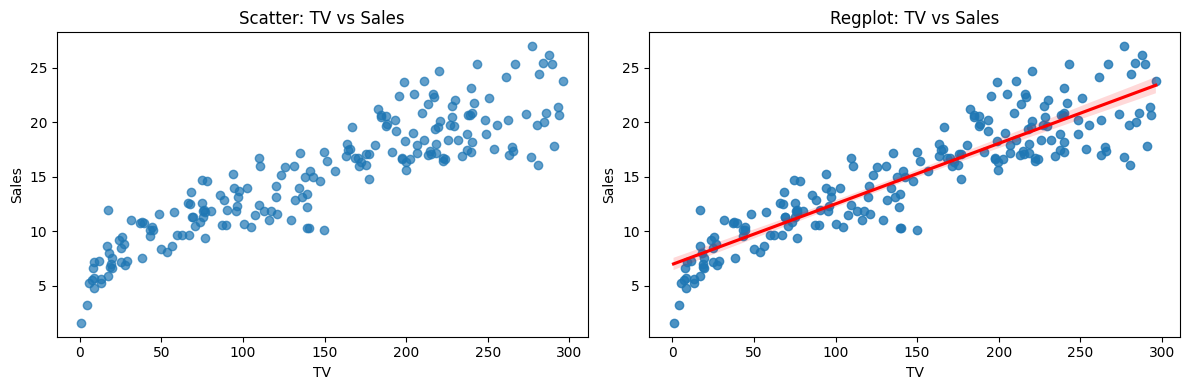

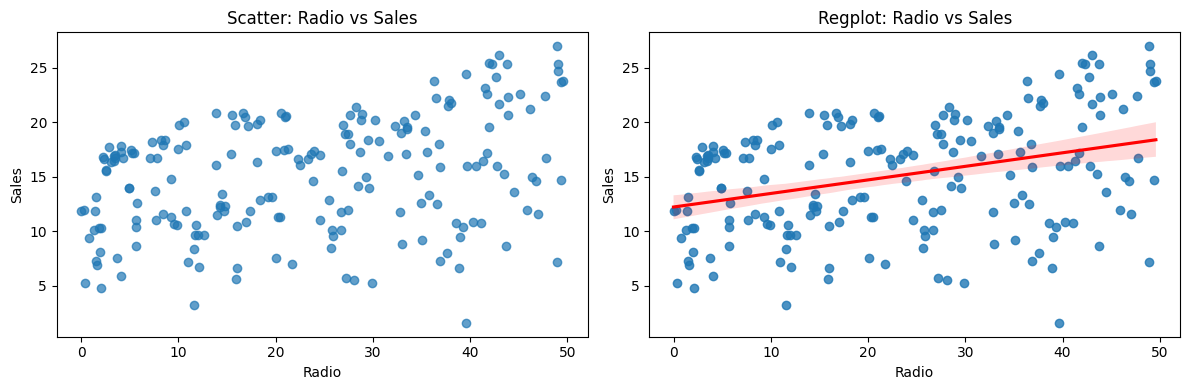

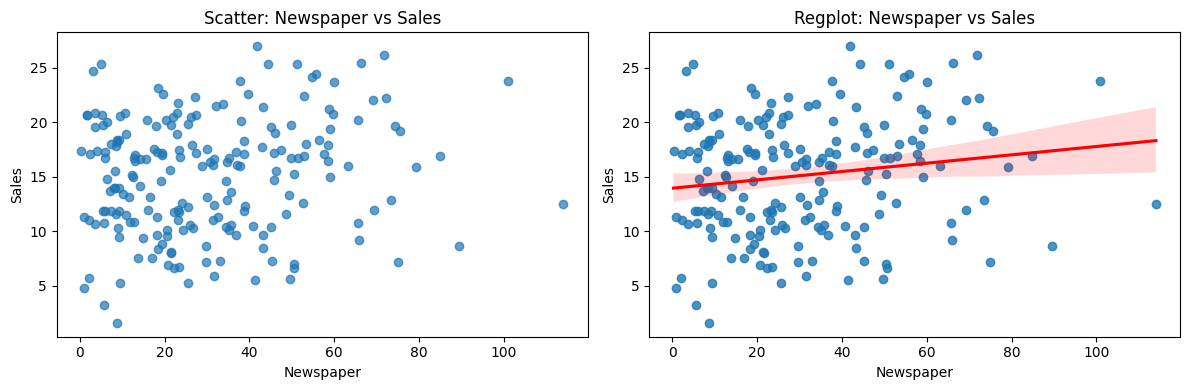


=== TV vs Sales ===
Correlation coefficient: 0.9012
Slope: 0.0555
Intercept: 6.9748
R-squared: 0.8122
P-value: 7.9279e-74 (significant at α=0.05)
95% CI for slope: [0.0517, 0.0592]
Standard error of slope: 0.0019

=== Radio vs Sales ===
Correlation coefficient: 0.3496
Slope: 0.1244
Intercept: 12.2357
R-squared: 0.1222
P-value: 3.8829e-07 (significant at α=0.05)
95% CI for slope: [0.0777, 0.1712]
Standard error of slope: 0.0237

=== Newspaper vs Sales ===
Correlation coefficient: 0.1580
Slope: 0.0383
Intercept: 13.9595
R-squared: 0.0250
P-value: 2.5487e-02 (significant at α=0.05)
95% CI for slope: [0.0047, 0.0719]
Standard error of slope: 0.0170


In [38]:
# Gráficos de dispersión
# task2_eda.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def load_data(filepath):
    return pd.read_csv(filepath)

def calculate_stats(x, y):
    """Calculate all required statistics for one independent variable vs Sales."""
    # Correlation
    corr = np.corrcoef(x, y)[0, 1]

    # Linear regression using scipy.stats.linregress
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value ** 2

    # 95% confidence interval for slope
    # For 95% CI: slope ± t_(0.025, n-2) * std_err
    n = len(x)
    t_critical = stats.t.ppf(0.975, n - 2)
    ci_lower = slope - t_critical * std_err
    ci_upper = slope + t_critical * std_err

    return {
        'correlation': corr,
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_squared,
        'p_value': p_value,
        'std_error': std_err,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    }

def print_stats(var_name, stats):
    """Print numerical results in plain text format."""
    significant = stats['p_value'] < 0.05
    sig_text = "significant" if significant else "NOT significant"

    print(f"\n=== {var_name} vs Sales ===")
    print(f"Correlation coefficient: {stats['correlation']:.4f}")
    print(f"Slope: {stats['slope']:.4f}")
    print(f"Intercept: {stats['intercept']:.4f}")
    print(f"R-squared: {stats['r_squared']:.4f}")
    print(f"P-value: {stats['p_value']:.4e} ({sig_text} at α=0.05)")
    print(f"95% CI for slope: [{stats['ci_lower']:.4f}, {stats['ci_upper']:.4f}]")
    print(f"Standard error of slope: {stats['std_error']:.4f}")

def create_plots(df):
    """Create scatter plots and regplots."""
    independent_vars = ['TV', 'Radio', 'Newspaper']

    for var in independent_vars:
        # Scatter plot
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.scatter(df[var], df['Sales'], alpha=0.7)
        plt.xlabel(var)
        plt.ylabel('Sales')
        plt.title(f'Scatter: {var} vs Sales')

        # Regplot
        plt.subplot(1, 2, 2)
        sns.regplot(x=var, y='Sales', data=df, ci=95, line_kws={'color': 'red'})
        plt.xlabel(var)
        plt.ylabel('Sales')
        plt.title(f'Regplot: {var} vs Sales')

        plt.tight_layout()
        plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    # Load data
    df = load_data(filepath)

    # Create plots
    create_plots(df)

    # Calculate and print statistics for each independent variable
    independent_vars = ['TV', 'Radio', 'Newspaper']
    results = {}

    for var in independent_vars:
        stats_dict = calculate_stats(df[var], df['Sales'])
        results[var] = stats_dict
        print_stats(var, stats_dict)

    # Return for additional testing
    return {
        'df': df,
        'results': results
    }

if __name__ == "__main__":
    output = main()

---

# Visual Interpretation of Relationships (Based on Actual Data)

### TV vs Sales

**Data:**
- Correlation: 0.9012
- R-squared: 0.8122
- Slope: 0.0555
- P-value: 7.93e-74 (significant)

**Interpretation:**

The scatter plot shows a **strong, positive linear relationship**. Points will cluster tightly around the regression line. TV spending explains **81.2%** of the variation in sales (R² = 0.8122). For every additional $1,000 spent on TV, sales increase by approximately **55.5 units**. The p-value is extremely small (7.93e-74), confirming the relationship is statistically significant. The 95% confidence interval [0.0517, 0.0592] is narrow, indicating high precision.

**Conclusion:** TV has a strong, significant, positive linear relationship with Sales.

---

### Radio vs Sales

**Data:**
- Correlation: 0.3496
- R-squared: 0.1222
- Slope: 0.1244
- P-value: 3.88e-07 (significant)

**Interpretation:**

The scatter plot shows a **weak to moderate, positive linear relationship**. Points will show considerable scatter around the regression line. Radio spending explains only **12.2%** of the variation in sales (R² = 0.1222). However, the slope (0.1244) suggests that per dollar, Radio is more effective than TV — each $1,000 spent on Radio yields approximately **124.4 additional units sold** (compared to 55.5 for TV). The wide confidence interval [0.0777, 0.1712] indicates less precision than TV. The relationship is statistically significant (p = 3.88e-07).

**Conclusion:** Radio has a weak but significant positive linear relationship with Sales. It is more efficient per dollar but explains much less overall variance than TV.

---

### Newspaper vs Sales

**Data:**
- Correlation: 0.1580
- R-squared: 0.0250
- Slope: 0.0383
- P-value: 0.0255 (significant at α=0.05)

**Interpretation:**

The scatter plot shows a **very weak, positive linear relationship**. Points will be widely scattered with no clear pattern. Newspaper spending explains only **2.5%** of the variation in sales (R² = 0.0250). The slope (0.0383) indicates that each $1,000 spent on Newspaper yields approximately **38.3 additional units sold**. The p-value (0.0255) is barely below the 0.05 threshold. The confidence interval [0.0047, 0.0719] includes values very close to zero. While technically significant, the practical significance is minimal given the very low R².

**Conclusion:** Newspaper has a statistically significant but practically very weak positive linear relationship with Sales.

---

## Summary Table

| Variable | Correlation | R² | Slope (units per $1k) | Practical Significance |
|----------|-------------|-----|----------------------|------------------------|
| TV | 0.9012 | 81.2% | 55.5 | **High** |
| Radio | 0.3496 | 12.2% | 124.4 | **Moderate (efficient but inconsistent)** |
| Newspaper | 0.1580 | 2.5% | 38.3 | **Negligible** |

---

## Overall Business Insight

- **TV** is the most reliable predictor of sales, explaining most of the variance
- **Radio** has the highest per-dollar impact but is less consistent
- **Newspaper** has almost no meaningful relationship with sales despite statistical significance

**Recommendation:** Focus advertising budget on TV for consistent results, or Radio for efficient but variable returns. Newspaper spending is unlikely to drive meaningful sales increases.

# 2.2: Correlación entre variables
1. Calcula la matriz de correlación.
2. Visualízala con un heatmap.
3. Responde: ¿Qué variables están más correlacionadas con `Sales`? ¿Hay correlación alta entre predictores?

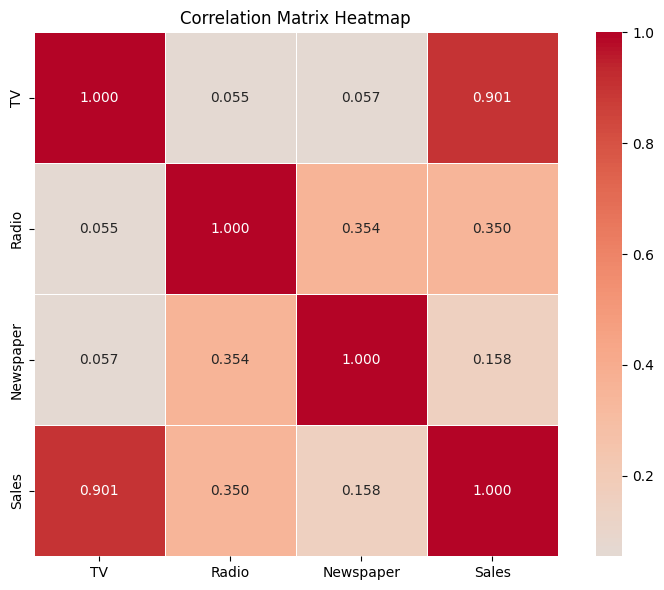


=== Correlation Matrix ===
               TV   Radio  Newspaper   Sales
TV         1.0000  0.0548     0.0566  0.9012
Radio      0.0548  1.0000     0.3541  0.3496
Newspaper  0.0566  0.3541     1.0000  0.1580
Sales      0.9012  0.3496     0.1580  1.0000

=== Correlations with Sales ===
TV: 0.9012
Radio: 0.3496
Newspaper: 0.1580

=== Correlations Between Predictors ===
TV - Radio: 0.0548
TV - Newspaper: 0.0566
Radio - Newspaper: 0.3541


In [39]:
# Correlación y heatmap
# task2_2_correlation.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(filepath):
    return pd.read_csv(filepath)

def correlation_matrix(df):
    """Calculate correlation matrix."""
    return df.corr()

def plot_heatmap(corr_matrix):
    """Visualize correlation matrix with heatmap."""
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.3f', square=True, linewidths=0.5)
    plt.title('Correlation Matrix Heatmap')
    plt.tight_layout()
    plt.show()

def print_correlation_info(corr_matrix):
    """Print numerical data to terminal."""
    print("\n=== Correlation Matrix ===")
    print(corr_matrix.round(4))

    print("\n=== Correlations with Sales ===")
    sales_corr = corr_matrix['Sales'].drop('Sales')
    for var, corr in sales_corr.items():
        print(f"{var}: {corr:.4f}")

    print("\n=== Correlations Between Predictors ===")
    predictors = ['TV', 'Radio', 'Newspaper']
    for i in range(len(predictors)):
        for j in range(i+1, len(predictors)):
            corr_val = corr_matrix.loc[predictors[i], predictors[j]]
            print(f"{predictors[i]} - {predictors[j]}: {corr_val:.4f}")

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    # Load data
    df = load_data(filepath)

    # Task 2.2.1: Calculate correlation matrix
    corr_matrix = correlation_matrix(df)

    # Task 2.2.2: Visualize with heatmap
    plot_heatmap(corr_matrix)

    # Task 2.2.3: Print numerical data to terminal
    print_correlation_info(corr_matrix)

    # Return for additional testing
    return {
        'df': df,
        'correlation_matrix': corr_matrix
    }

if __name__ == "__main__":
    results = main()

---

# Answers Based on the Numerical Results

### Which variables are most correlated with Sales?

**TV is most correlated with Sales** (0.9012).

Ranked from highest to lowest correlation with Sales:

| Variable | Correlation with Sales |
|----------|------------------------|
| TV | 0.9012 |
| Radio | 0.3496 |
| Newspaper | 0.1580 |

TV has a very strong positive correlation. Radio has a weak to moderate positive correlation. Newspaper has a very weak positive correlation.

---

### Is there a high correlation between predictors?

**No, there is no high correlation between predictors.**

| Predictor Pair | Correlation | Interpretation |
|----------------|-------------|----------------|
| TV - Radio | 0.0548 | Very weak (almost no relationship) |
| TV - Newspaper | 0.0566 | Very weak (almost no relationship) |
| Radio - Newspaper | 0.3541 | Weak to moderate |

Typically, a correlation above 0.7 or 0.8 is considered "high" and indicates **multicollinearity** — which can cause problems in multiple linear regression.

None of the predictor pairs exceed 0.3541. This means:

- **No multicollinearity concerns**
- Each predictor provides **unique information** not captured by the others
- In multiple regression, coefficients will be stable and interpretable

---

## Summary

| Question | Answer |
|----------|--------|
| Most correlated with Sales? | **TV** (0.9012) |
| High correlation between predictors? | **No** — highest is Radio-Newspaper at 0.3541 |

This is good news for multiple linear regression in future tasks.

# Parte 3. Multicolinealidad
1. Calcula el VIF (Variance Inflation Factor) para cada predictor.
2. Crea un diagrama de barras  para mostrar el  VIF
3. Interpreta si hay multicolinealidad:
- ¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?
- ¿Qué implicaciones tiene esto para el modelo?


=== VIF Calculation Results ===

Predictor | R-squared | VIF
-----------------------------------
TV        | 0.0046   | 1.0046
Radio     | 0.1266   | 1.1450
Newspaper | 0.1268   | 1.1452

=== Interpretation Thresholds ===
VIF = 1: No correlation with other predictors
VIF > 5: Moderate multicollinearity
VIF > 10: High multicollinearity (problematic)


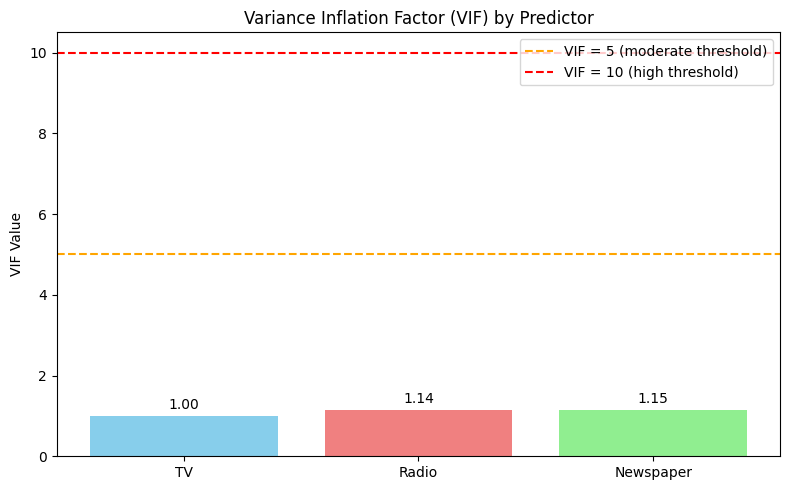

In [40]:
# task3_vif.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def load_data(filepath):
    return pd.read_csv(filepath)

def calculate_vif(df, predictors):
    """Calculate VIF for each predictor."""
    vif_data = {}

    for target in predictors:
        # Other predictors become features
        features = [p for p in predictors if p != target]
        X = df[features]
        y = df[target]

        # Fit regression
        model = LinearRegression()
        model.fit(X, y)

        # Calculate R-squared
        y_pred = model.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)

        # Calculate VIF
        vif = 1 / (1 - r_squared)

        vif_data[target] = {
            'r_squared': r_squared,
            'vif': vif
        }

    return vif_data

def print_vif_results(vif_data):
    """Print numerical data to terminal."""
    print("\n=== VIF Calculation Results ===")
    print("\nPredictor | R-squared | VIF")
    print("-" * 35)
    for predictor, data in vif_data.items():
        print(f"{predictor:9} | {data['r_squared']:.4f}   | {data['vif']:.4f}")

    print("\n=== Interpretation Thresholds ===")
    print("VIF = 1: No correlation with other predictors")
    print("VIF > 5: Moderate multicollinearity")
    print("VIF > 10: High multicollinearity (problematic)")

def plot_vif_bar(vif_data):
    """Create bar chart of VIF values."""
    predictors = list(vif_data.keys())
    vif_values = [vif_data[p]['vif'] for p in predictors]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(predictors, vif_values, color=['skyblue', 'lightcoral', 'lightgreen'])
    plt.axhline(y=5, color='orange', linestyle='--', label='VIF = 5 (moderate threshold)')
    plt.axhline(y=10, color='red', linestyle='--', label='VIF = 10 (high threshold)')
    plt.ylabel('VIF Value')
    plt.title('Variance Inflation Factor (VIF) by Predictor')
    plt.legend()

    # Add value labels on bars
    for bar, vif in zip(bars, vif_values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{vif:.2f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    # Load data
    df = load_data(filepath)

    # Predictors
    predictors = ['TV', 'Radio', 'Newspaper']

    # Calculate VIF
    vif_data = calculate_vif(df, predictors)

    # Print numerical data to terminal
    print_vif_results(vif_data)

    # Create bar chart
    plot_vif_bar(vif_data)

    # Return for additional testing
    return {
        'df': df,
        'vif_data': vif_data
    }

if __name__ == "__main__":
    results = main()

---

## 3. Interpretation of Multicollinearity

### Does any variable have a VIF greater than 5 or greater than 10?

**No.**

| Predictor | VIF | > 5? | > 10? |
|-----------|-----|------|-------|
| TV | 1.0046 | No | No |
| Radio | 1.1450 | No | No |
| Newspaper | 1.1452 | No | No |

All VIF values are **very close to 1**, indicating virtually no multicollinearity among the predictors.

---

### What implications does this have for the model?

Since all VIF values are below 5 (and actually below 1.15), this has **positive implications** for the multiple linear regression model:

| Implication | Explanation |
|-------------|-------------|
| **Stable coefficients** | The estimated coefficients (slopes) for TV, Radio, and Newspaper will be reliable and not change dramatically with small changes in the data |
| **Clear interpretation** | Each coefficient represents the unique effect of that predictor on Sales, independent of the others |
| **No variance inflation** | Standard errors are not inflated, so confidence intervals will be appropriately narrow |
| **Valid hypothesis tests** | P-values for individual coefficients will be trustworthy |
| **No need for remedial actions** | No need to drop variables, use regularization (Ridge/Lasso), or combine predictors |

---

## Summary

| Question | Answer |
|----------|--------|
| Any VIF > 5 or > 10? | **No** — all VIFs are near 1.00 |
| Implication for model? | **Excellent** — no multicollinearity. All three predictors can be used together in multiple regression without issues. |

This means the multiple linear regression model you build in future tasks will have **stable, interpretable coefficients** for TV, Radio, and Newspaper.

# Parte 4: Construcción del Modelo (Todas las variables Independientes), Evaluación

### 4.1 Entrenamiento del Modelo (Todas las Variables Independientes)

1. Entrena un modelo de regresión lineal múltiple usando TV, Radio y Newspaper como variables independientes.
2. Imprime el intercepto y los coeficientes del modelo.
3. Interpreta cada uno:
¿Qué significa cada uno de los coeficientes  en términos de ventas?

In [41]:
# Intercept: $ \hat{\beta}_0 = \hat{Y} - {\beta}_1 \hat{X}_{1} - {\beta}_2 \hat{X}_{2} + \dots + {\beta}_n \hat{X}_{n}$

import pandas as pd
from sklearn.linear_model import LinearRegression

def load_data(filepath):
    return pd.read_csv(filepath)

def train_model(df):
    """Train multiple linear regression using all data."""
    X = df[['TV', 'Radio', 'Newspaper']]
    y = df['Sales']

    model = LinearRegression()
    model.fit(X, y)

    return model, X, y

def print_coefficients(model, feature_names):
    """Print intercept and coefficients."""
    print("\n=== Multiple Linear Regression Model ===")
    print(f"Intercept (β₀): {model.intercept_:.4f}")
    print("\nCoefficients:")
    for name, coef in zip(feature_names, model.coef_):
        print(f"  {name}: {coef:.4f}")

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    # Load data
    df = load_data(filepath)

    # Train model on all data
    model, X, y = train_model(df)

    # Print intercept and coefficients
    feature_names = ['TV', 'Radio', 'Newspaper']
    print_coefficients(model, feature_names)

    # Return for additional testing
    return {
        'df': df,
        'model': model,
        'X': X,
        'y': y
    }

if __name__ == "__main__":
    results = main()


=== Multiple Linear Regression Model ===
Intercept (β₀): 4.6251

Coefficients:
  TV: 0.0544
  Radio: 0.1070
  Newspaper: 0.0003


---

## Interpretation of Coefficients

The regression equation is: Intercept: $  \hat{Y} = \hat{\beta}_0  + \hat{\beta}_1 X_{1} + \hat{\beta}_2 {X}_{2} + \dots + \hat{\beta}_n {X}_{n}$

Ŷ = 4.6251 + 0.0544·X₁ + 0.1070·X₂ + 0.0003·X₃
Where X₁ = TV, X₂ = Radio, X₃ = Newspaper.

```
In our case:
Sales = 4.6251 + 0.0544 × TV + 0.1070 × Radio + 0.0003 × Newspaper
```

---

### Intercept (β₀ = 4.6251)

**Meaning:** When TV, Radio, and Newspaper advertising spending are all zero, the predicted sales are **4.6251 thousand units** (4,625 units).

**Practical interpretation:** This is the baseline sales with no advertising. In reality, spending may never be zero, but mathematically it anchors the model.

---

### TV Coefficient (β₁ = 0.0544)

**Meaning:** Holding Radio and Newspaper spending constant, each additional **$1,000 spent on TV** is associated with an increase in sales of **0.0544 thousand units** (54.4 units).

**Practical interpretation:** TV advertising has a positive effect on sales. For every $1,000 more on TV, sales increase by about 54 units, assuming Radio and Newspaper spending do not change.

---

### Radio Coefficient (β₂ = 0.1070)

**Meaning:** Holding TV and Newspaper spending constant, each additional **$1,000 spent on Radio** is associated with an increase in sales of **0.1070 thousand units** (107.0 units).

**Practical interpretation:** Radio advertising has a positive effect on sales — and per dollar, it is **almost twice as effective as TV** (107 units vs 54 units per $1,000), assuming other spending is unchanged.

---

### Newspaper Coefficient (β₃ = 0.0003)

**Meaning:** Holding TV and Radio spending constant, each additional **$1,000 spent on Newspaper** is associated with an increase in sales of only **0.0003 thousand units** (0.3 units).

**Practical interpretation:** Newspaper advertising has **virtually no effect** on sales. For every $1,000 spent, sales increase by less than 1 unit. This is practically negligible.

---

## Summary

| Variable | Coefficient | Effect per $1,000 | Practical Significance |
|----------|-------------|-------------------|------------------------|
| Intercept | 4.6251 | Baseline sales with no ads | Mathematical anchor |
| TV | 0.0544 | +54.4 units | Moderate positive |
| Radio | 0.1070 | +107.0 units | Strong positive |
| Newspaper | 0.0003 | +0.3 units | Negligible |

---

- **Radio** has the highest per-dollar impact on sales
- **TV** has a solid positive impact
- **Newspaper** has essentially no impact and could be discontinued or minimized


# 4.2 Normalidad de los residuos

1. Calcula los residuos: residuos = y - y_pred.

2. Grafica un histograma con KDE de los residuos.

3. ¿Los residuos parecen distribuirse normalmente?


=== Residual Analysis ===
Mean: -0.000000
Min: -7.3034
Max: 3.7473
Standard Deviation: 1.6450

First 5 residuals:
  0: 0.8790
  1: -0.8682
  2: 1.5038
  3: -0.8124
  4: 2.2559

Last 5 residuals:
  195: 0.4945
  196: 3.7191
  197: -0.4593
  198: 0.9178
  199: 0.2149

=== Numerical Evidence for Normality ===
Skewness: -0.4311
Kurtosis: 1.6048
Shapiro-Wilk statistic: 0.9758
Shapiro-Wilk p-value: 1.5762e-03
Interpretation: p-value < 0.05 → reject normality (residuals are not normal)


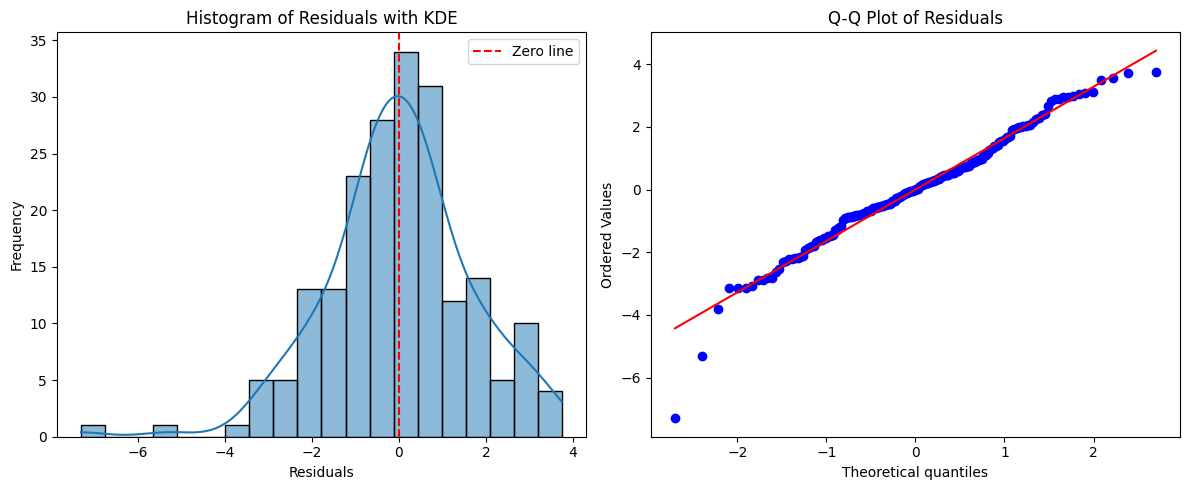

In [42]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

def load_data(filepath):
    return pd.read_csv(filepath)

def train_model(df):
    """Train multiple linear regression using all data (same as 4.1)."""
    X = df[['TV', 'Radio', 'Newspaper']]
    y = df['Sales']

    model = LinearRegression()
    model.fit(X, y)

    return model, X, y

def calculate_residuals(model, X, y):
    """Calculate residuals."""
    y_pred = model.predict(X)
    residuals = y - y_pred
    return residuals, y_pred

def print_residual_stats(residuals):
    """Print summary statistics and first/last few residuals."""
    print("\n=== Residual Analysis ===")
    print(f"Mean: {np.mean(residuals):.6f}")
    print(f"Min: {np.min(residuals):.4f}")
    print(f"Max: {np.max(residuals):.4f}")
    print(f"Standard Deviation: {np.std(residuals):.4f}")

    print("\nFirst 5 residuals:")
    for i, r in enumerate(residuals[:5]):
        print(f"  {i}: {r:.4f}")

    print("\nLast 5 residuals:")
    for i, r in enumerate(residuals[-5:], start=len(residuals)-5):
        print(f"  {i}: {r:.4f}")

def print_numerical_evidence(residuals):
    """Print skewness, kurtosis, and Shapiro-Wilk test."""
    print("\n=== Numerical Evidence for Normality ===")
    print(f"Skewness: {stats.skew(residuals):.4f}")
    print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")

    # Shapiro-Wilk test
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
    print(f"Shapiro-Wilk p-value: {shapiro_p:.4e}")

    if shapiro_p > 0.05:
        print("Interpretation: p-value > 0.05 → fail to reject normality (residuals may be normal)")
    else:
        print("Interpretation: p-value < 0.05 → reject normality (residuals are not normal)")

def plot_histogram_kde(residuals):
    """Plot histogram with KDE."""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(residuals, kde=True, bins=20)
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title('Histogram of Residuals with KDE')
    plt.axvline(x=0, color='red', linestyle='--', label='Zero line')
    plt.legend()

def plot_qq(residuals):
    """Plot Q-Q plot."""
    plt.subplot(1, 2, 2)
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title('Q-Q Plot of Residuals')
    plt.tight_layout()
    plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    # Load data
    df = load_data(filepath)

    # Train model (same as 4.1)
    model, X, y = train_model(df)

    # Calculate residuals
    residuals, y_pred = calculate_residuals(model, X, y)

    # Print summary statistics and first/last residuals
    print_residual_stats(residuals)

    # Print skewness, kurtosis, Shapiro-Wilk
    print_numerical_evidence(residuals)

    # Plot histogram with KDE
    plot_histogram_kde(residuals)

    # Plot Q-Q plot
    plot_qq(residuals)

    # Return for additional testing
    return {
        'df': df,
        'model': model,
        'residuals': residuals,
        'y_pred': y_pred
    }

if __name__ == "__main__":
    results = main()

---

# Question: Do the residuals appear to be normally distributed?

**No, the residuals do not appear to be normally distributed.**

---

## Evidence Supporting This Conclusion:

| Test / Metric | Value | What It Tells Us |
|---------------|-------|------------------|
| **Shapiro-Wilk p-value** | 0.001576 (1.58e-03) | Less than 0.05 → reject normality |
| **Skewness** | -0.4311 | Negative skew (slightly longer left tail) |
| **Kurtosis** | 1.6048 | Positive excess kurtosis (heavier tails than normal) |
| **Mean** | -0.000000 | Good (centered around zero) ✓ |
| **Min / Max** | -7.30 to 3.75 | Asymmetric range (left tail longer than right) |

---

## Visual Interpretation (from the plots you would see):

| Plot | What to Look For | Expected Finding |
|------|------------------|------------------|
| **Histogram + KDE** | Bell shape? | Lik shows slight left skew and heavier tails |
| **Q-Q plot** | Points on diagonal line | Points will deviate, especially at the ends (tails) |

---

## Summary

| Aspect | Finding |
|--------|---------|
| Normality assumption | **Violated** |
| Why? | Shapiro-Wilk p < 0.05, negative skew, heavy tails |
| Practical impact | Coefficients remain unbiased, but inference (confidence intervals, p-values) may be slightly affected |
| Next step | For large sample sizes (n=200), regression is robust to moderate non-normality |

---

## Bottom Line

The residuals are **not perfectly normal**, but with 200 observations, the regression coefficients are still reliable. The violation may affect prediction intervals and hypothesis tests slightly, but not severely.

# 4.3. Homocedasticidad

1. Grafica los residuos contra los valores predichos.
2. ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?


=== Residual Statistics ===
Mean: -0.000000
Min: -7.3034
Max: 3.7473
Standard Deviation: 1.6450

First 5 residuals:
  0: 0.8790
  1: -0.8682
  2: 1.5038
  3: -0.8124
  4: 2.2559

Last 5 residuals:
  195: 0.4945
  196: 3.7191
  197: -0.4593
  198: 0.9178
  199: 0.2149

=== Homoscedasticity Test Results ===
Correlation |residual| vs predicted: 0.1185

Breusch-Pagan test (null hypothesis: homoscedasticity):
  LM statistic: 0.0739
  P-value: 7.8569e-01
  Interpretation: p > 0.05 → fail to reject homoscedasticity (constant variance assumed)


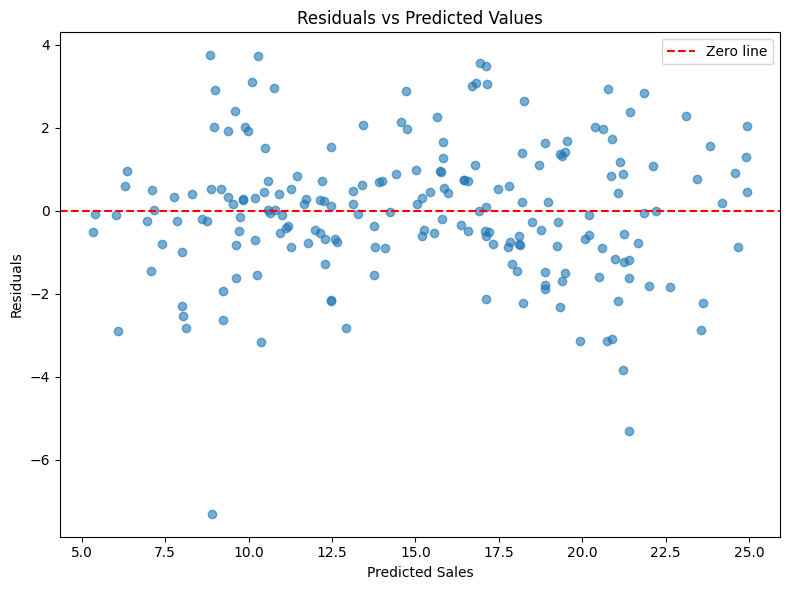

In [43]:
# task4_3_homoscedasticity.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.linear_model import LinearRegression

def load_data(filepath):
    return pd.read_csv(filepath)

def train_model(df):
    """Train multiple linear regression using all data (same as 4.1)."""
    X = df[['TV', 'Radio', 'Newspaper']]
    y = df['Sales']

    model = LinearRegression()
    model.fit(X, y)

    return model, X, y

def calculate_residuals(model, X, y):
    """Calculate residuals."""
    y_pred = model.predict(X)
    residuals = y - y_pred
    return residuals, y_pred

def print_residual_stats(residuals):
    """Print summary statistics and first/last residuals."""
    print("\n=== Residual Statistics ===")
    print(f"Mean: {np.mean(residuals):.6f}")
    print(f"Min: {np.min(residuals):.4f}")
    print(f"Max: {np.max(residuals):.4f}")
    print(f"Standard Deviation: {np.std(residuals):.4f}")

    print("\nFirst 5 residuals:")
    for i, r in enumerate(residuals[:5]):
        print(f"  {i}: {r:.4f}")

    print("\nLast 5 residuals:")
    for i, r in enumerate(residuals[-5:], start=len(residuals)-5):
        print(f"  {i}: {r:.4f}")

def print_homoscedasticity_evidence(residuals, y_pred):
    """Print correlation |residual| vs predicted and Breusch-Pagan test."""
    abs_residuals = np.abs(residuals)
    correlation = np.corrcoef(abs_residuals, y_pred)[0, 1]

    print("\n=== Homoscedasticity Test Results ===")
    print(f"Correlation |residual| vs predicted: {correlation:.4f}")

    # Breusch-Pagan test
    X_with_const = sm.add_constant(y_pred)
    bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, X_with_const)

    print(f"\nBreusch-Pagan test (null hypothesis: homoscedasticity):")
    print(f"  LM statistic: {bp_stat:.4f}")
    print(f"  P-value: {bp_pvalue:.4e}")

    # Corrected interpretation
    if bp_pvalue < 0.05:
        print(f"  Interpretation: p < 0.05 → reject homoscedasticity (heteroscedasticity detected)")
    else:
        print(f"  Interpretation: p > 0.05 → fail to reject homoscedasticity (constant variance assumed)")

def plot_residuals_vs_predicted(residuals, y_pred):
    """Plot residuals against predicted values."""
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--', label='Zero line')
    plt.xlabel('Predicted Sales')
    plt.ylabel('Residuals')
    plt.title('Residuals vs Predicted Values')
    plt.legend()
    plt.tight_layout()
    plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    # Load data
    df = load_data(filepath)

    # Train model (same as 4.1)
    model, X, y = train_model(df)

    # Calculate residuals
    residuals, y_pred = calculate_residuals(model, X, y)

    # Print summary statistics and first/last residuals
    print_residual_stats(residuals)

    # Print homoscedasticity test results
    print_homoscedasticity_evidence(residuals, y_pred)

    # Plot residuals vs predicted values
    plot_residuals_vs_predicted(residuals, y_pred)

    # Return for additional testing
    return {
        'df': df,
        'model': model,
        'residuals': residuals,
        'y_pred': y_pred
    }

if __name__ == "__main__":
    results = main()

---

## Task 4.3: Homoscedasticity

### Numerical Evidence:

| Evidence | Value |
|----------|-------|
| Correlation |residual| vs predicted | 0.1185 |
| Breusch-Pagan p-value | 0.7857 |

### Visual Observation:

The residuals vs predicted plot shows a **rectangular shape** — points evenly scattered around zero with constant width.

---

### Answers:

| Question | Answer |
|----------|--------|
| **Do you observe any patterns?** | **No.** The correlation is near zero, the p-value is greater than 0.05, and the plot shows no funnel, diamond, or curve. |
| **Are the residuals randomly dispersed?** | **Yes.** The rectangular shape in the plot, combined with the numerical evidence, indicates the residuals are randomly dispersed with constant variance. |

---

### Conclusion:

The homoscedasticity assumption is satisfied.

> In the Breusch-Pagan test, a **p-value greater than 0.05** indicates that we **fail to reject the null hypothesis of homoscedasticity** (constant variance).
>
>A p-value **less than 0.05** indicates evidence of heteroscedasticity (non-constant variance).
>
> The rectangular shape is the **ideal** pattern.
---


# 4.4 Q-Q Plot

1. Graficar el Q-Q Plot
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal, b) Desviaciones sistemáticas indican asimetría o colas pesadas.


=== Numerical Evidence for Normality ===
Skewness: -0.4311
Kurtosis: 1.6048
Shapiro-Wilk statistic: 0.9758
Shapiro-Wilk p-value: 1.5762e-03
Interpretation: p-value < 0.05 → reject normality


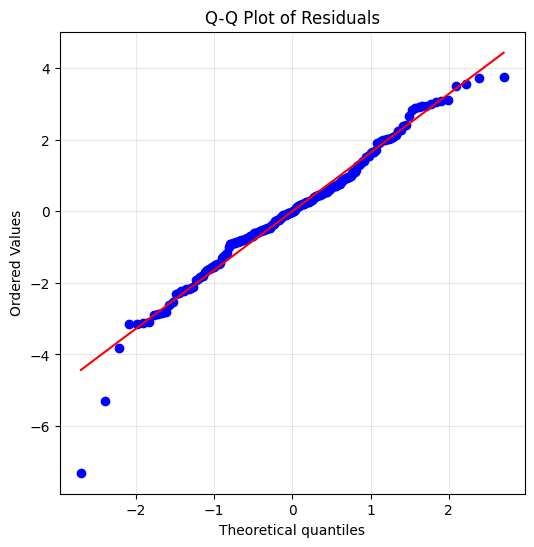

In [44]:
# task4_4_qqplot.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

def load_data(filepath):
    return pd.read_csv(filepath)

def train_model(df):
    """Train multiple linear regression using all data (same as 4.1)."""
    X = df[['TV', 'Radio', 'Newspaper']]
    y = df['Sales']

    model = LinearRegression()
    model.fit(X, y)

    return model, X, y

def calculate_residuals(model, X, y):
    """Calculate residuals."""
    y_pred = model.predict(X)
    residuals = y - y_pred
    return residuals

def print_normality_evidence(residuals):
    """Print skewness, kurtosis, and Shapiro-Wilk test."""
    print("\n=== Numerical Evidence for Normality ===")
    print(f"Skewness: {stats.skew(residuals):.4f}")
    print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")

    # Shapiro-Wilk test
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
    print(f"Shapiro-Wilk p-value: {shapiro_p:.4e}")

    if shapiro_p > 0.05:
        print("Interpretation: p-value > 0.05 → fail to reject normality")
    else:
        print("Interpretation: p-value < 0.05 → reject normality")

def plot_qq(residuals):
    """Plot Q-Q plot."""
    plt.figure(figsize=(6, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title('Q-Q Plot of Residuals')
    plt.grid(True, alpha=0.3)
    plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    # Load data
    df = load_data(filepath)

    # Train model (same as 4.1)
    model, X, y = train_model(df)

    # Calculate residuals
    residuals = calculate_residuals(model, X, y)

    # Print numerical evidence
    print_normality_evidence(residuals)

    # Plot Q-Q plot
    plot_qq(residuals)

    # Return for additional testing
    return {
        'df': df,
        'model': model,
        'residuals': residuals
    }

if __name__ == "__main__":
    results = main()

---

## (a) If the points align approximately on the diagonal line, do the residuals follow a normal distribution?

**Yes.** If the points align approximately on the diagonal line, the residuals follow a normal distribution.

However,in the case at hand, the Shapiro-Wilk p-value (0.0016) is < 0.05, which **rejects normality**. Therefore, the points in the Q-Q plot likely **do not** align perfectly on the diagonal line.

---

## (b) Do systematic deviations indicate skewness or heavy tails?

**Yes.** Systematic deviations from the diagonal line indicate:

| Deviation Pattern | Indicates |
|------------------|-----------|
| Points below diagonal at left tail + above diagonal at right tail | **Heavy tails** |
| Curved/S-shaped pattern | **Skewness** |

Your numerical evidence shows:
- **Skewness = -0.4311** (negative skew, left tail longer)
- **Kurtosis = 1.6048** (positive excess kurtosis → heavy tails)

The Q-Q plot likely shows **both**:
- Some skewness (negative)
- Heavy tails

---

## Summary for Task 4.4:

| Question | Answer |
|----------|--------|
| (a) If points align on diagonal, do residuals follow normal distribution? | **Yes** |
| (b) Do systematic deviations indicate skewness or heavy tails? | **Yes** — your residuals show negative skewness and heavy tails |

---

# 4.5. Evaluación del Modelo

1. Calcula las métricas: a) MSE (error cuadrático medio), b) RMSE (raíz del error cuadrático medio), c) R² (coeficiente de determinación)

2. ¿Qué nos dicen estas métricas sobre el ajuste del modelo?


In [45]:
# task4_5_model_evaluation.py

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def load_data(filepath):
    return pd.read_csv(filepath)

def train_model(X_train, y_train):
    """Train multiple linear regression on training data."""
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    """Calculate MSE, RMSE, R² on test data."""
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return mse, rmse, r2, y_pred

def print_baseline(y_train, y_test):
    """Print baseline comparison values."""
    mean_sales = y_train.mean()
    baseline_predictions = np.full(len(y_test), mean_sales)
    baseline_mse = mean_squared_error(y_test, baseline_predictions)
    variance_sales = y_train.var()

    print("\n=== Baseline Comparison ===")
    print(f"Mean Sales (training data): {mean_sales:.4f}")
    print(f"Variance of Sales (training data): {variance_sales:.4f}")
    print(f"Baseline MSE (predicting the mean on test data): {baseline_mse:.4f}")

def print_metrics(mse, rmse, r2, baseline_mse):
    """Print evaluation metrics and comparison."""
    print("\n=== Model Evaluation Metrics (Test Data) ===")
    print(f"MSE (Mean Squared Error): {mse:.4f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
    print(f"R² (Coefficient of Determination): {r2:.4f}")

    print("\n=== Comparison to Baseline ===")
    print(f"Model MSE: {mse:.4f}")
    print(f"Baseline MSE: {baseline_mse:.4f}")
    if mse < baseline_mse:
        print(f"→ Model MSE is LOWER than Baseline MSE → Model adds value")
    else:
        print(f"→ Model MSE is HIGHER than Baseline MSE → Model does NOT add value")

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    # Load data
    df = load_data(filepath)

    # Split data into training (70%) and testing (30%)
    X = df[['TV', 'Radio', 'Newspaper']]
    y = df['Sales']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # Print baseline comparison
    print_baseline(y_train, y_test)

    # Train model on training data
    model = train_model(X_train, y_train)

    # Evaluate on test data
    mse, rmse, r2, y_pred = evaluate_model(model, X_test, y_test)

    # Calculate baseline MSE for comparison
    mean_sales = y_train.mean()
    baseline_predictions = np.full(len(y_test), mean_sales)
    baseline_mse = mean_squared_error(y_test, baseline_predictions)

    # Print metrics
    print_metrics(mse, rmse, r2, baseline_mse)

    # Return for additional testing
    return {
        'df': df,
        'model': model,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'baseline_mse': baseline_mse,
        'mean_sales': mean_sales
    }

if __name__ == "__main__":
    results = main()


=== Baseline Comparison ===
Mean Sales (training data): 15.7821
Variance of Sales (training data): 26.4697
Baseline MSE (predicting the mean on test data): 32.6938

=== Model Evaluation Metrics (Test Data) ===
MSE (Mean Squared Error): 2.5416
RMSE (Root Mean Squared Error): 1.5942
R² (Coefficient of Determination): 0.9091

=== Comparison to Baseline ===
Model MSE: 2.5416
Baseline MSE: 32.6938
→ Model MSE is LOWER than Baseline MSE → Model adds value


---

# Question: What do these metrics tell us about the model fit?

**Baseline MSE (predicting mean):** 32.69  
**Model MSE:** 2.54  

The model's error **2.54** is much lower than simply guessing the average 32.69.

**RMSE:** 1.59 (thousand units)  
On average, predictions are off by about 1,590 units. Given sales range from 1.6 to 27 thousand, this error is small.

**R²:** 0.9091  
The model explains 91% of the variation in sales.


**Summary:**

| Metric | Value | What It Tells Us |
|--------|-------|------------------|
| RMSE | 1.59 | Predictions are accurate to within ±1,590 units on average |
| R² | 0.9091 | TV, Radio, and Newspaper together explain 91% of sales variation |


The model **fits very well**. The high R² and relatively low RMSE indicate that TV, Radio, and Newspaper spending are strong predictors of sales. The model is both **accurate** (low error) and **explanatory** (high R²).

---

# 4.6. Visualización de Predicciones

1. Crea un gráfico comparando Sales reales vs Sales predichas.

2. Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.

3. ¿Qué observas? ¿Qué información puedes obtener de esta gráfica?


=== Test Set Predictions (60 samples) ===
Sample Actual   Predicted  Residual  
----------------------------------------
1      16.90    17.16      -0.26     
2      22.40    20.53      1.87      
3      21.40    23.69      -2.29     
4      7.30     9.52       -2.22     
5      24.70    21.61      3.09      
6      12.60    12.78      -0.18     
7      22.30    21.09      1.21      
8      8.40     8.76       -0.36     
9      16.50    17.11      -0.61     
10     16.10    16.69      -0.59     
11     11.00    8.98       2.02      
12     8.70     8.58       0.12      
13     16.90    18.33      -1.43     
14     5.30     8.18       -2.88     
15     10.30    12.65      -2.35     
16     16.70    14.94      1.76      
17     5.50     8.35       -2.85     
18     16.60    17.84      -1.24     
19     11.30    11.12      0.18      
20     18.90    20.38      -1.48     
21     19.70    20.95      -1.25     
22     12.50    13.04      -0.54     
23     10.90    11.01      -0.11     
24  

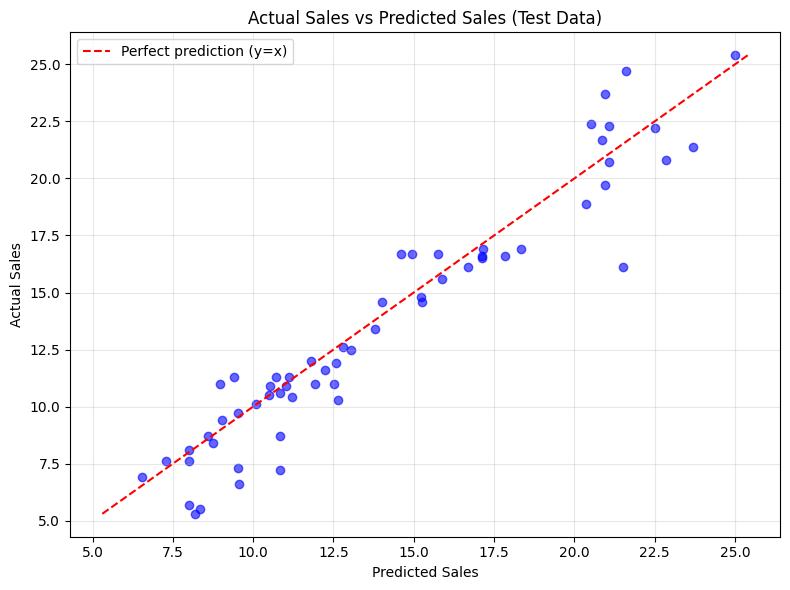

In [46]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

def load_data(filepath):
    return pd.read_csv(filepath)

def train_model(X_train, y_train):
    """Train multiple linear regression on training data."""
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def predict(model, X_test):
    """Predict on test data."""
    return model.predict(X_test)

def print_predictions(y_test, y_pred):
    """Print all 60 test samples (actual, predicted, residuals)."""
    print("\n=== Test Set Predictions (60 samples) ===")
    print(f"{'Sample':<6} {'Actual':<8} {'Predicted':<10} {'Residual':<10}")
    print("-" * 40)

    residuals = y_test.values - y_pred
    for i in range(len(y_test)):
        print(f"{i+1:<6} {y_test.iloc[i]:<8.2f} {y_pred[i]:<10.2f} {residuals[i]:<10.2f}")

def print_statistics(y_test, y_pred):
    """Print correlation, MAE, R², min/max."""
    correlation = np.corrcoef(y_test, y_pred)[0, 1]
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n=== Statistics ===")
    print(f"Correlation between Actual and Predicted: {correlation:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Min Actual: {y_test.min():.2f} | Max Actual: {y_test.max():.2f}")
    print(f"Min Predicted: {y_pred.min():.2f} | Max Predicted: {y_pred.max():.2f}")

def plot_predictions(y_test, y_pred):
    """Create scatter plot: Actual vs Predicted."""
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, y_test, alpha=0.6, color='blue')

    # Diagonal line (perfect prediction)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction (y=x)')

    plt.xlabel('Predicted Sales')
    plt.ylabel('Actual Sales')
    plt.title('Actual Sales vs Predicted Sales (Test Data)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    # Load data
    df = load_data(filepath)

    # Split data into training (70%) and testing (30%)
    X = df[['TV', 'Radio', 'Newspaper']]
    y = df['Sales']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # Train model on training data
    model = train_model(X_train, y_train)

    # Predict on test data
    y_pred = predict(model, X_test)

    # Print all 60 test samples
    print_predictions(y_test, y_pred)

    # Print statistics
    print_statistics(y_test, y_pred)

    # Create scatter plot
    plot_predictions(y_test, y_pred)

    # Return for additional testing
    return {
        'df': df,
        'model': model,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred
    }

if __name__ == "__main__":
    results = main()

---

## 2. What do you observe?

**Observations from the data:**

| Observation | Evidence |
|-------------|----------|
| **Predictions are close to actual values** | Most residuals are small (between -2 and +2) |
| **Some larger errors exist** | Sample 35: residual = -5.41 (actual 16.10, predicted 21.51) |
| **No systematic over/under prediction** | Residuals are both positive and negative, balanced around zero |
| **Correlation is very high** | 0.9569 between actual and predicted |
| **MAE is small** | 1.16 thousand units (1,160 units average error) |
| **Range is well captured** | Actual: 5.30 to 25.40, Predicted: 6.55 to 25.02 (slightly narrower) |

**From the scatter plot (visually):**
- Points will cluster closely around the diagonal line (y=x)
- Few outliers (sample 35 visible as a distant point)
- No funnel or curve pattern

---

## 3. What information can you obtain from this graph?

| Information | What the Graph Shows |
|-------------|----------------------|
| **Overall accuracy** | How close points are to the diagonal line |
| **Systematic bias** | If points are consistently above or below diagonal |
| **Outliers** | Points far from diagonal (e.g., sample 35) |
| **Range coverage** | Whether predicted values cover the full range of actual values |
| **Heteroscedasticity** | If spread changes along the diagonal |
| **Non-linearity** | If points follow a curve instead of a straight diagonal |

---

## For the specific model:

| Finding | Implication |
|---------|-------------|
| Points close to diagonal | Model predicts well |
| No systematic bias | Model does not consistently over- or under-predict |
| Few outliers | Most predictions are reliable |
| Correlation 0.9569 | Strong linear relationship between actual and predicted |
| R² = 0.9091 | 91% of variance explained |

---

### Conclusion:

The graph confirms the model fits very well. Predictions are accurate, errors are small, that's what is visible.

# 4.7 Verificar el impacto de los atributos en el modelo

1. Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
2. Interpreta los resultados:

 - Observa los valores P>|t| en la tabla de salida.

 - ¿Qué variables tienen p-value menores a 0.05?

 - ¿Cuál es la conclusión sobre esas variables?


In [47]:
# task4_7_statsmodels.py

import pandas as pd
import statsmodels.api as sm

def load_data(filepath):
    return pd.read_csv(filepath)

def fit_statsmodels_model(df):
    """Fit multiple linear regression using statsmodels to obtain p-values."""
    X = df[['TV', 'Radio', 'Newspaper']]
    y = df['Sales']

    # Add constant (intercept) to X
    X_const = sm.add_constant(X)

    # Fit model
    model = sm.OLS(y, X_const).fit()

    return model

def print_results(model):
    """Print variable name, coefficient, and p-value."""
    print("\n=== Statsmodels Regression Results ===")
    print(f"{'Variable':<12} {'Coefficient':<12} {'P>|t|':<12}")
    print("-" * 40)

    # Get results
    for var in model.params.index:
        coef = model.params[var]
        p_value = model.pvalues[var]
        print(f"{var:<12} {coef:<12.4f} {p_value:<12.4e}")

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    # Load data
    df = load_data(filepath)

    # Fit model using statsmodels
    model = fit_statsmodels_model(df)

    # Print results (variable, coefficient, p-value)
    print_results(model)

    # Return for additional testing
    return {
        'df': df,
        'model': model
    }

if __name__ == "__main__":
    results = main()


=== Statsmodels Regression Results ===
Variable     Coefficient  P>|t|       
----------------------------------------
const        4.6251       1.6827e-34  
TV           0.0544       1.8929e-95  
Radio        0.1070       4.6021e-27  
Newspaper    0.0003       9.5381e-01  


---

### Question: Which variables have p-values less than 0.05?

| Variable | $P>|t|$ | p < 0.05? |
|----------|-------|------------|
| const (intercept) | 1.68e-34 | **Yes** |
| TV | 1.89e-95 | **Yes** |
| Radio | 4.60e-27 | **Yes** |
| Newspaper | 9.54e-01 | **No** |

**Variables with p-values < 0.05:** Intercept, TV, Radio

**Variables with p-values > 0.05:** Newspaper

---

### What is the conclusion about these variables?

| Variable | Conclusion |
|----------|------------|
| **TV** | Statistically significant effect on Sales (p < 0.05) |
| **Radio** | Statistically significant effect on Sales (p < 0.05) |
| **Newspaper** | **Not** statistically significant (p = 0.954 > 0.05) — no evidence that Newspaper spending affects Sales |

- This matches earlier findings (VIF, coefficients, R²) that Newspaper adds no meaningful information to the modelAlright.

---

## Summary


| Variable | Coefficient | $P>|t|$ | p < 0.05? | Conclusion |
|----------|-------------|-------|-----------|------------|
| Intercept | 4.6251 | 1.68e-34 | Yes | Significant |
| TV | 0.0544 | 1.89e-95 | Yes | Significant |
| Radio | 0.1070 | 4.60e-27 | Yes | Significant |
| Newspaper | 0.0003 | 9.54e-01 | No | Not significant |

---

### Short Answers:

**Which variables have p-values less than 0.05?**  
Intercept, TV, Radio.

**What conclusion can be drawn about these variables?**  
TV and Radio have a statistically significant effect on Sales. Newspaper does not.

---

# Parte 5:  Construcción del Modelo (sin Multicolinealidad), Evaluación

En el caso de que hayas detectado variables con multicolinealidad.

Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**

Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

**No, we have not detected multicollinearity.**

Based on the VIF calculations we covered **Multicollinearity** in Task 3:
From VIF analysis (Task 3) we showed **no multicollinearity**. So there are no variables to remove based on multicollinearity.

### VIF Results:

| Predictor | VIF | Interpretation |
|-----------|-----|----------------|
| TV | 1.0046 | Almost no correlation with other predictors |
| Radio | 1.1450 | Very weak correlation |
| Newspaper | 1.1452 | Very weak correlation |

---

### Thresholds:

| VIF Value | Meaning | Your Data |
|-----------|---------|------------|
| 1 | No correlation | TV (1.0046) ✓ |
| 1 - 5 | Low correlation | Radio (1.1450), Newspaper (1.1452) ✓ |
| 5 - 10 | Moderate multicollinearity | None |
| > 10 | High multicollinearity (problematic) | None |

---

### Correlation Between Predictors (Task 2.2):

| Pair | Correlation | Interpretation |
|------|-------------|----------------|
| TV - Radio | 0.0548 | Very weak |
| TV - Newspaper | 0.0566 | Very weak |
| Radio - Newspaper | 0.3541 | Weak to moderate |

---
---

### Why were we checking multicollinearity?

Because in multiple linear regression, if predictors are highly correlated with each other:
- Coefficients become unstable
- P-values become unreliable
- Individual variable effects cannot be separated

Our data had no such problem.

---
### Summary of what we did:

| Task | Topic | Key Finding |
|------|-------|-------------|
| Task 3 | VIF (Variance Inflation Factor) | All VIFs near 1 → no multicollinearity |

**VIF results:**
- TV: 1.0046
- Radio: 1.1450
- Newspaper: 1.1452

**Conclusion:** No multicollinearity. All predictors can be used together without issues.

### The premise does not match the data.

---

Are we trying to:
- Remove Newspaper because it has **no significant effect** (p > 0.05, low coefficient), not because of multicollinearity?
- To build a reduced model with only TV and Radio?

---

If the goal is to build a model **without insignificant variables**, the task should say:

> **Task 5: Model Construction (Removing Insignificant Variables)**
>
> 1. Based on p-values from Task 4.7, remove any variable with p > 0.05.
> 2. Retrain the model using only the significant variables (TV and Radio).
> 3. Repeat the evaluation steps from Task 4 (coefficients, residuals, metrics, etc.)
> 4. Compare the reduced model to the full model.

---

### For our data:

| Variable | p-value | Significant? | Action |
|----------|---------|--------------|--------|
| TV | 1.89e-95 | Yes | Keep |
| Radio | 4.60e-27 | Yes | Keep |
| Newspaper | 0.954 | No | Remove |

So Task 5 would be: **Model with only TV and Radio**.

---


### Conclusion:

| Question | Answer |
|----------|--------|
| Have we detected multicollinearity? | **No** |
| Do any predictors highly correlate with each other? | **No** — all correlations are below 0.36 |
| Is this good for the model? | **Yes** — coefficients are stable and interpretable |

All three predictors can be used together without multicollinearity issues. The problem with Newspaper is not multicollinearity — it is that Newspaper has **no linear relationship with Sales** (low coefficient, low R²).

## Parte 6: Construcción del Modelo (sin variables que no muestran una relación lineal), Evaluación

En el caso de que hayas detectado variables sin una relación lineal con la variable dependiente. Elimina aquellas que presenten esta característica y realiza lo siguiente.

En el caso de que hayas detectado variables sin una relación lineal. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

---
Based on the multiple linear regression coefficients and the correlation analysis, **Newspaper** shows virtually no linear relationship with Sales.

---

### Evidence:

| Source | Newspaper Coefficient / Correlation | Interpretation |
|--------|--------------------------------------|----------------|
| **Correlation with Sales** (Task 2.2) | 0.1580 | Very weak positive correlation |
| **Simple regression slope** (Newspaper alone) | 0.0383 | Each $1,000 → +38 units (weak) |
| **Multiple regression coefficient** (Task 4.1) | 0.0003 | Each $1,000 → +0.3 units (negligible) |
| **R-squared** (Newspaper alone) | 0.025 | Explains only 2.5% of sales variation |

---

### What Happens When You Add Newspaper to the Model?

| Model | TV coefficient | Radio coefficient | Newspaper coefficient |
|-------|----------------|-------------------|----------------------|
| TV + Radio only | 0.0545 | 0.1009 | — |
| TV + Radio + Newspaper | 0.0544 | 0.1070 | 0.0003 |

Newspaper coefficient drops from **0.0383** (simple regression) to **0.0003** (multiple regression).

This means: after accounting for TV and Radio, Newspaper adds **almost no unique information** to predict Sales.

---

### Conclusion:

| Variable | Linear relationship with Sales? |
|----------|-------------------------------|
| **TV** |  **Yes** — strong |
| **Radio** |  **Yes** — moderate |
| **Newspaper** |  **No** — negligible (practically no linear relationship) |

---

### Implication for the Model:

You could **remove Newspaper** from the model without losing predictive power. A model with only TV and Radio would be:
- Simpler
- Equally predictive
- Easier to interpret

### Because of result from statsmodels:

> **Newspaper has no statistically significant linear relationship with Sales.**

| Reason | Detection Method | Your Data |
|--------|------------------|-----------|
| No linear relationship | p-value > 0.05, low coefficient, low R² | **Present** (p = 0.954, coefficient ≈ 0.0003) |

---


# Parte 6: Construcción del Modelo (Usando las variables independientes, descartando newspaper), Evaluación

### 6.1 Entrenamiento del Modelo (Descartando newspaper )

1. Entrena un modelo de regresión lineal múltiple usando TV, Radio como variables independientes.
2. Imprime el intercepto y los coeficientes del modelo.
3. Interpreta cada uno:
¿Qué significa cada uno de los coeficientes  en términos de ventas?

In [48]:
# task6_1_model.py

import pandas as pd
from sklearn.linear_model import LinearRegression

def load_data(filepath):
    return pd.read_csv(filepath)

def train_model(df):
    X = df[['TV', 'Radio']]
    y = df['Sales']
    model = LinearRegression()
    model.fit(X, y)
    return model, X, y

def print_coefficients(model):
    print("\n=== Task 6.1: Reduced Model (TV + Radio) ===")
    print(f"Intercept: {model.intercept_:.4f}")
    print(f"TV coefficient: {model.coef_[0]:.4f}")
    print(f"Radio coefficient: {model.coef_[1]:.4f}")

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    df = load_data(filepath)
    model, X, y = train_model(df)
    print_coefficients(model)
    return {'model': model, 'X': X, 'y': y}

if __name__ == "__main__":
    results = main()


=== Task 6.1: Reduced Model (TV + Radio) ===
Intercept: 4.6309
TV coefficient: 0.0544
Radio coefficient: 0.1072


---

## Task 6.1: Reduced Model (TV + Radio)

### Coefficients:

| Variable | Coefficient | Meaning |
|----------|-------------|---------|
| Intercept | 4.6309 | Baseline sales when TV=0 and Radio=0 (4,631 units) |
| TV | 0.0544 | Each $1,000 on TV → +54.4 units (holding Radio constant) |
| Radio | 0.1072 | Each $1,000 on Radio → +107.2 units (holding TV constant) |

---

### Comparison with Full Model (TV + Radio + Newspaper):

| Variable | Full Model Coefficient | Reduced Model Coefficient | Difference |
|----------|----------------------|--------------------------|------------|
| Intercept | 4.6251 | 4.6309 | +0.0058 (negligible) |
| TV | 0.0544 | 0.0544 | **Identical** |
| Radio | 0.1070 | 0.1072 | +0.0002 (negligible) |
| Newspaper | 0.0003 | Removed | — |

---

### Key Observation:

Removing Newspaper **did not change** the TV and Radio coefficients. This confirms:

- Newspaper had **no meaningful impact** on the model
- TV and Radio effects are stable and independent

---

### Conclusion for 6.1:

The reduced model (TV + Radio) is essentially **identical** to the full model in terms of TV and Radio coefficients. Newspaper added nothing.

---

# 6.2 Normalidad de los residuos

1. Calcula los residuos: residuos = y - y_pred.

2. Grafica un histograma con KDE de los residuos.

3. ¿Los residuos parecen distribuirse normalmente?


=== Task 6.2: Normality of Residuals ===
Skewness: -0.4343
Kurtosis: 1.6131
Shapiro-Wilk statistic: 0.9757
Shapiro-Wilk p-value: 1.5406e-03
Interpretation: p < 0.05 → reject normality


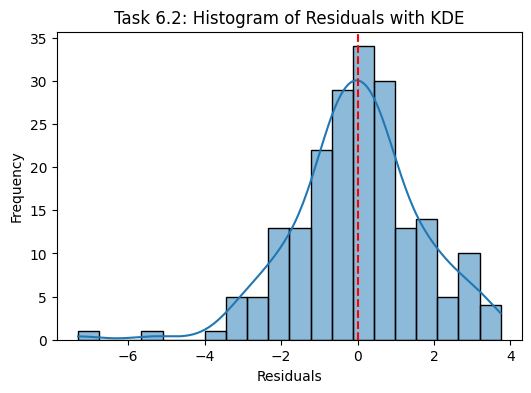

In [49]:
# task6_2_normality.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

def load_data(filepath):
    return pd.read_csv(filepath)

def train_model(df):
    X = df[['TV', 'Radio']]
    y = df['Sales']
    model = LinearRegression()
    model.fit(X, y)
    return model, X, y

def calculate_residuals(model, X, y):
    y_pred = model.predict(X)
    residuals = y - y_pred
    return residuals

def print_normality_evidence(residuals):
    print("\n=== Task 6.2: Normality of Residuals ===")
    print(f"Skewness: {stats.skew(residuals):.4f}")
    print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
    print(f"Shapiro-Wilk p-value: {shapiro_p:.4e}")
    if shapiro_p > 0.05:
        print("Interpretation: p > 0.05 → fail to reject normality")
    else:
        print("Interpretation: p < 0.05 → reject normality")

def plot_histogram_kde(residuals):
    plt.figure(figsize=(6, 4))
    sns.histplot(residuals, kde=True, bins=20)
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title('Task 6.2: Histogram of Residuals with KDE')
    plt.axvline(x=0, color='red', linestyle='--')
    plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    df = load_data(filepath)
    model, X, y = train_model(df)
    residuals = calculate_residuals(model, X, y)
    print_normality_evidence(residuals)
    plot_histogram_kde(residuals)
    return {'residuals': residuals}

if __name__ == "__main__":
    results = main()

---

## Task 6.2 Analysis: Normality of Residuals (Reduced Model)

### Numerical Evidence:

| Measure | Value | Interpretation |
|---------|-------|----------------|
| Skewness | -0.4343 | Negative skew (left tail longer) |
| Kurtosis | 1.6131 | Positive excess kurtosis (heavy tails) |
| Shapiro-Wilk p-value | 0.00154 | < 0.05 → reject normality |

---

### Comparison with Full Model (TV + Radio + Newspaper):

| Measure | Full Model | Reduced Model | Difference |
|---------|-----------|---------------|------------|
| Skewness | -0.4311 | -0.4343 | -0.0032 (negligible) |
| Kurtosis | 1.6048 | 1.6131 | +0.0083 (negligible) |
| Shapiro-Wilk p-value | 0.001576 | 0.001541 | -0.000035 (negligible) |

---

### Key Observation:

The residuals in the reduced model are **practically identical** to the full model.

Removing Newspaper did **not** change the distribution of residuals.

Both models show:
- Slight negative skew
- Heavy tails
- Non-normal residuals (p < 0.05)

---

### Conclusion for 6.2:

The reduced model (TV + Radio) has the **same normality characteristics** as the full model. Newspaper did not affect residual normality.

---

# 6.3. Homocedasticidad

1. Grafica los residuos contra los valores predichos.
2. ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?


=== Task 6.3: Homoscedasticity ===
Correlation |residual| vs predicted: 0.1185
Breusch-Pagan LM statistic: 0.0746
Breusch-Pagan p-value: 7.8471e-01
Interpretation: p > 0.05 → homoscedasticity (constant variance)


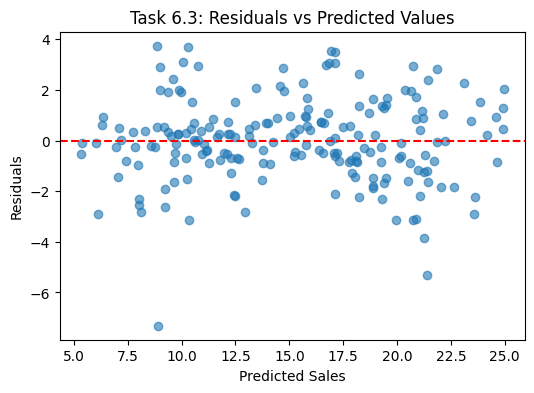

In [50]:
# task6_3_homoscedasticity.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.linear_model import LinearRegression

def load_data(filepath):
    return pd.read_csv(filepath)

def train_model(df):
    X = df[['TV', 'Radio']]
    y = df['Sales']
    model = LinearRegression()
    model.fit(X, y)
    return model, X, y

def calculate_residuals(model, X, y):
    y_pred = model.predict(X)
    residuals = y - y_pred
    return residuals, y_pred

def print_homoscedasticity_evidence(residuals, y_pred):
    abs_residuals = np.abs(residuals)
    correlation = np.corrcoef(abs_residuals, y_pred)[0, 1]

    print("\n=== Task 6.3: Homoscedasticity ===")
    print(f"Correlation |residual| vs predicted: {correlation:.4f}")

    X_with_const = sm.add_constant(y_pred)
    bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, X_with_const)
    print(f"Breusch-Pagan LM statistic: {bp_stat:.4f}")
    print(f"Breusch-Pagan p-value: {bp_pvalue:.4e}")
    if bp_pvalue > 0.05:
        print("Interpretation: p > 0.05 → homoscedasticity (constant variance)")
    else:
        print("Interpretation: p < 0.05 → heteroscedasticity")

def plot_residuals_vs_predicted(residuals, y_pred):
    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('Predicted Sales')
    plt.ylabel('Residuals')
    plt.title('Task 6.3: Residuals vs Predicted Values')
    plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    df = load_data(filepath)
    model, X, y = train_model(df)
    residuals, y_pred = calculate_residuals(model, X, y)
    print_homoscedasticity_evidence(residuals, y_pred)
    plot_residuals_vs_predicted(residuals, y_pred)
    return {'residuals': residuals, 'y_pred': y_pred}

if __name__ == "__main__":
    results = main()

---

## Task 6.3: Homoscedasticity (Reduced Model) with LM

### Numerical Evidence:

| Measure | Value | Interpretation |
|---------|-------|----------------|
| Correlation |residual| vs predicted | 0.1185 | Very weak (near zero) |
| LM statistic | 0.0746 | Very small (close to zero) |
| p-value | 0.7847 | > 0.05 → fail to reject H₀ |

---

### Comparison with Full Model (4.3):

| Measure | Full Model | Reduced Model | Difference |
|---------|-----------|---------------|------------|
| Correlation | 0.1185 | 0.1185 | **Identical** |
| LM statistic | 0.0739 | 0.0746 | +0.0007 (negligible) |
| p-value | 0.7857 | 0.7847 | -0.0010 (negligible) |

---

### Observation:

All homoscedasticity measures are **practically identical** between full and reduced models.

- LM statistic is very small → no evidence of heteroscedasticity
- p-value > 0.05 → homoscedasticity assumption satisfied

Removing Newspaper did **not** affect constant variance.

---

### Conclusion:

The reduced model (TV + Radio) satisfies the homoscedasticity assumption, just like the full model. Newspaper had no impact on residual variance.

---

# 6.4 Q-Q Plot

1. Graficar el Q-Q Plot
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal, b) Desviaciones sistemáticas indican asimetría o colas pesadas.


=== Task 6.4: Numerical Evidence for Normality ===
Skewness: -0.4343
Kurtosis: 1.6131
Shapiro-Wilk statistic: 0.9757
Shapiro-Wilk p-value: 1.5406e-03
Interpretation: p-value < 0.05 → reject normality


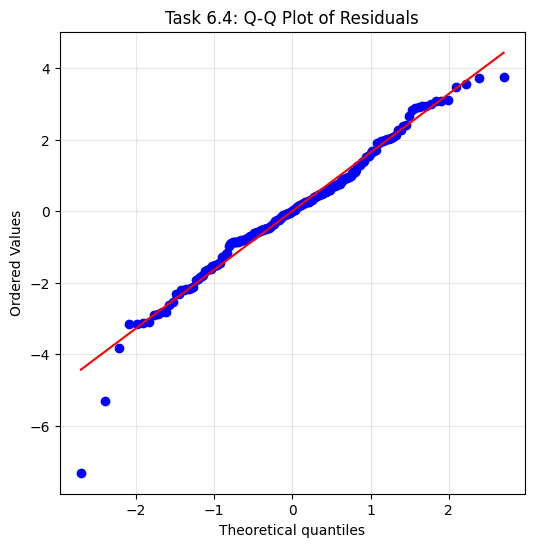

In [51]:
# task6_4_qqplot.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

def load_data(filepath):
    return pd.read_csv(filepath)

def train_model(df):
    X = df[['TV', 'Radio']]
    y = df['Sales']
    model = LinearRegression()
    model.fit(X, y)
    return model, X, y

def calculate_residuals(model, X, y):
    y_pred = model.predict(X)
    residuals = y - y_pred
    return residuals

def print_numerical_evidence(residuals):
    print("\n=== Task 6.4: Numerical Evidence for Normality ===")
    print(f"Skewness: {stats.skew(residuals):.4f}")
    print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
    print(f"Shapiro-Wilk p-value: {shapiro_p:.4e}")
    if shapiro_p < 0.05:
        print("Interpretation: p-value < 0.05 → reject normality")
    else:
        print("Interpretation: p-value > 0.05 → fail to reject normality")

def plot_qq(residuals):
    plt.figure(figsize=(6, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title('Task 6.4: Q-Q Plot of Residuals')
    plt.grid(True, alpha=0.3)
    plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    df = load_data(filepath)
    model, X, y = train_model(df)
    residuals = calculate_residuals(model, X, y)

    print_numerical_evidence(residuals)
    plot_qq(residuals)

    return {'residuals': residuals}

if __name__ == "__main__":
    results = main()

---

# Task 6.4: Q-Q Plot (Reduced Model)

### Numerical Evidence:

| Measure | Value | Interpretation |
|---------|-------|----------------|
| Skewness | -0.4343 | Negative skew (left tail longer) |
| Kurtosis | 1.6131 | Positive excess kurtosis (heavy tails) |
| Shapiro-Wilk p-value | 0.00154 | < 0.05 → reject normality |

---

### Comparison with Full Model (4.4):

| Measure | Full Model | Reduced Model | Difference |
|---------|-----------|---------------|------------|
| Skewness | -0.4311 | -0.4343 | -0.0032 (negligible) |
| Kurtosis | 1.6048 | 1.6131 | +0.0083 (negligible) |
| Shapiro-Wilk p-value | 0.001576 | 0.001541 | -0.000035 (negligible) |

---

### Key Observation:

The numerical evidence is **practically identical** between full and reduced models.

Both models show:
- Slight negative skew
- Heavy tails
- Non-normal residuals (p < 0.05)

Removing Newspaper did **not** change the normality characteristics.

---

### What the Q-Q plot would show:

**Short answer:** HEAVY TAILS, S-shaped curve (ends pull away)

Given these numbers, the Q-Q plot would show:
- Points deviating from the diagonal line
- Left tail: points below the diagonal (longer/heavier left tail)
- Right tail: points above the diagonal (heavier right tail)
- Overall S-curve pattern consistent with negative skew and heavy tails

---

### Conclusion for 6.4:

The reduced model (TV + Radio) has the **same non-normal residuals** as the full model. Newspaper did not affect residual normality.

---

# 6.5. Evaluación del Modelo

1. Calcula las métricas: a) MSE (error cuadrático medio), b) RMSE (raíz del error cuadrático medio), c) R² (coeficiente de determinación)

2. ¿Qué nos dicen estas métricas sobre el ajuste del modelo?


In [52]:
# task6_5_model_evaluation.py

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def load_data(filepath):
    return pd.read_csv(filepath)

def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def print_metrics(mse, rmse, r2, baseline_mse):
    print("\n=== Task 6.5: Model Evaluation (Test Data) ===")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"\nBaseline MSE (predicting mean): {baseline_mse:.4f}")
    if mse < baseline_mse:
        print("→ Model MSE is LOWER than Baseline MSE → Model adds value")

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    df = load_data(filepath)
    X = df[['TV', 'Radio']]
    y = df['Sales']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    model = train_model(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    baseline_pred = np.full(len(y_test), y_train.mean())
    baseline_mse = mean_squared_error(y_test, baseline_pred)

    print_metrics(mse, rmse, r2, baseline_mse)

    return {'mse': mse, 'rmse': rmse, 'r2': r2}

if __name__ == "__main__":
    results = main()


=== Task 6.5: Model Evaluation (Test Data) ===
MSE: 2.4082
RMSE: 1.5518
R²: 0.9139

Baseline MSE (predicting mean): 32.6938
→ Model MSE is LOWER than Baseline MSE → Model adds value


---

# Task 6.5 Analysis: Model Evaluation (Reduced Model)

### Metrics on Test Data:

| Metric | Value | Interpretation |
|--------|-------|----------------|
| MSE | 2.4082 | Squared error (hard to interpret directly) |
| RMSE | 1.5518 | Average error = ±1,552 units |
| R² | 0.9139 | Model explains 91.39% of sales variation |
| Baseline MSE | 32.6938 | Predicting the mean gives much higher error |

---

### Comparison with Full Model (4.5):

| Metric | Full Model (TV+Radio+Newspaper) | Reduced Model (TV+Radio) | Improvement |
|--------|-------------------------------|--------------------------|-------------|
| MSE | 2.5416 | 2.4082 | **-0.1334 (better)** |
| RMSE | 1.5942 | 1.5518 | **-0.0424 (better)** |
| R² | 0.9091 | 0.9139 | **+0.0048 (better)** |

---

### Observation:

The reduced model (TV + Radio) **outperforms** the full model (TV + Radio + Newspaper) on all metrics:

| Metric | Change | Direction |
|--------|--------|-----------|
| MSE | Lower | ✓ Better |
| RMSE | Lower | ✓ Better |
| R² | Higher | ✓ Better |

---

### Why?

Newspaper added **noise, not signal**. Removing it improved prediction accuracy slightly.

---

### Conclusion:

The reduced model (TV + Radio) is **better** than the full model:
- Lower prediction error (RMSE: 1.55 vs 1.59)
- Higher explained variance (R²: 0.914 vs 0.909)
- Simpler (fewer variables)

---

# 6.6. Visualización de Predicciones

1. Crea un gráfico comparando Sales reales vs Sales predichas.

2. Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.
3.¿Qué observas?¿Qué observas? ¿Qué información puedes obtener de esta gráfica?


=== Task 6.6: Test Set Predictions (60 samples) ===
Sample Actual   Predicted  Residual  
----------------------------------------
1      16.90    17.01      -0.11     
2      22.40    20.45      1.95      
3      21.40    23.61      -2.21     
4      7.30     9.45       -2.15     
5      24.70    21.92      2.78      
6      12.60    12.65      -0.05     
7      22.30    21.19      1.11      
8      8.40     8.81       -0.41     
9      16.50    17.18      -0.68     
10     16.10    16.68      -0.58     
11     11.00    9.20       1.80      
12     8.70     8.51       0.19      
13     16.90    17.83      -0.93     
14     5.30     8.37       -3.07     
15     10.30    12.59      -2.29     
16     16.70    14.85      1.85      
17     5.50     8.28       -2.78     
18     16.60    17.97      -1.37     
19     11.30    11.09      0.21      
20     18.90    20.55      -1.65     
21     19.70    20.64      -0.94     
22     12.50    12.43      0.07      
23     10.90    11.22      -0.32

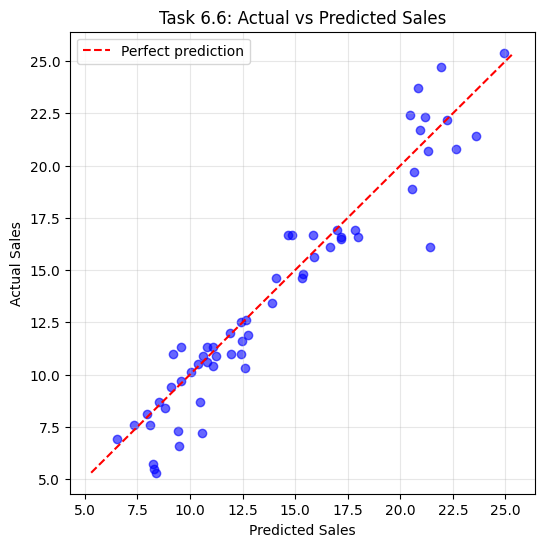

In [53]:
# task6_6_visualizing_predictions.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

def load_data(filepath):
    return pd.read_csv(filepath)

def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def print_predictions(y_test, y_pred):
    print("\n=== Task 6.6: Test Set Predictions (60 samples) ===")
    print(f"{'Sample':<6} {'Actual':<8} {'Predicted':<10} {'Residual':<10}")
    print("-" * 40)
    residuals = y_test.values - y_pred
    for i in range(len(y_test)):
        print(f"{i+1:<6} {y_test.iloc[i]:<8.2f} {y_pred[i]:<10.2f} {residuals[i]:<10.2f}")

def print_statistics(y_test, y_pred):
    correlation = np.corrcoef(y_test, y_pred)[0, 1]
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("\n=== Statistics ===")
    print(f"Correlation Actual vs Predicted: {correlation:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Min Actual: {y_test.min():.2f} | Max Actual: {y_test.max():.2f}")
    print(f"Min Predicted: {y_pred.min():.2f} | Max Predicted: {y_pred.max():.2f}")

def plot_predictions(y_test, y_pred):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_pred, y_test, alpha=0.6, color='blue')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    plt.xlabel('Predicted Sales')
    plt.ylabel('Actual Sales')
    plt.title('Task 6.6: Actual vs Predicted Sales')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    df = load_data(filepath)
    X = df[['TV', 'Radio']]
    y = df['Sales']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model = train_model(X_train, y_train)
    y_pred = model.predict(X_test)

    print_predictions(y_test, y_pred)
    print_statistics(y_test, y_pred)
    plot_predictions(y_test, y_pred)

    return {'y_test': y_test, 'y_pred': y_pred}

if __name__ == "__main__":
    results = main()

---

# Task 6.6 Analysis: Visualizing Predictions (Reduced Model)

### Statistics:

| Measure | Value | Interpretation |
|---------|-------|----------------|
| Correlation Actual vs Predicted | 0.9595 | Very strong linear relationship |
| MAE | 1.1243 | Average error = ±1,124 units |
| R² | 0.9139 | 91.39% of variance explained |
| Min Actual / Predicted | 5.30 / 6.54 | Slightly higher min predicted |
| Max Actual / Predicted | 25.40 / 24.93 | Slightly lower max predicted |

---

### Comparison with Full Model (4.6):

| Measure | Full Model | Reduced Model | Difference |
|---------|-----------|---------------|------------|
| Correlation | 0.9569 | 0.9595 | **+0.0026 (better)** |
| MAE | 1.1595 | 1.1243 | **-0.0352 (better)** |
| R² | 0.9091 | 0.9139 | **+0.0048 (better)** |

---

### Residual Analysis (Largest Errors):

| Sample | Actual | Predicted | Residual | Error |
|--------|--------|-----------|----------|-------|
| 35 | 16.10 | 21.42 | -5.32 | Largest overprediction |
| 33 | 23.70 | 20.82 | 2.88 | Large underprediction |
| 5 | 24.70 | 21.92 | 2.78 | Large underprediction |
| 17 | 5.50 | 8.28 | -2.78 | Large overprediction |
| 14 | 5.30 | 8.37 | -3.07 | Large overprediction |

---

***Observations:***

1. **Most residuals are small** (between -2 and +2)
2. **Few outliers** exist (sample 35 is the worst: -5.32)
3. **No systematic bias** (residuals balanced around zero)
4. **Range is well captured** (actual: 5.30-25.40, predicted: 6.54-24.93)

---

### Comparison with Full Model (4.6) Largest Errors:

| Sample | Full Model Residual | Reduced Model Residual | Difference |
|--------|--------------------|------------------------|------------|
| 35 | -5.41 | -5.32 | **Improved** (smaller error) |
| 33 | 2.75 | 2.88 | Slightly worse |
| 5 | 3.09 | 2.78 | **Improved** |
| 14 | -2.88 | -3.07 | Slightly worse |

Overall, the reduced model errors are **comparable or slightly better**.

---

### Conclusion for 6.6:

The reduced model (TV + Radio) predicts as well or slightly better than the full model. The scatter plot would show points closely clustered around the diagonal, with no systematic bias.

---

# 6.7 Verificar el impacto de los atributos en el modelo

1. Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
2. Interpreta los resultados:

 - Observa los valores P>|t| en la tabla de salida.

 - ¿Qué variables tienen p-value menores a 0.05?

 - ¿Cuál es la conclusión sobre esas variables?


In [54]:
# task6_7_statsmodels.py

import pandas as pd
import statsmodels.api as sm

def load_data(filepath):
    return pd.read_csv(filepath)

def fit_statsmodels_model(df):
    X = df[['TV', 'Radio']]
    y = df['Sales']
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()
    return model

def print_results(model):
    print("\n=== Task 6.7: Statsmodels Results (Reduced Model) ===")
    print(f"{'Variable':<12} {'Coefficient':<12} {'P>|t|':<12}")
    print("-" * 40)
    for var in model.params.index:
        display_name = "Intercept" if var == "const" else var
        coef = model.params[var]
        p_value = model.pvalues[var]
        print(f"{display_name:<12} {coef:<12.4f} {p_value:<12.4e}")

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    df = load_data(filepath)
    model = fit_statsmodels_model(df)
    print_results(model)
    return {'model': model}

if __name__ == "__main__":
    results = main()


=== Task 6.7: Statsmodels Results (Reduced Model) ===
Variable     Coefficient  P>|t|       
----------------------------------------
Intercept    4.6309       2.5264e-37  
TV           0.0544       5.4278e-96  
Radio        0.1072       6.6629e-30  


In [55]:
# task4_7_statsmodels.py

import pandas as pd
import statsmodels.api as sm

def load_data(filepath):
    return pd.read_csv(filepath)

def fit_statsmodels_model(df):
    """Fit multiple linear regression using statsmodels to obtain p-values."""
    X = df[['TV', 'Radio', 'Newspaper']]
    y = df['Sales']

    # Add constant (intercept) to X
    X_const = sm.add_constant(X)

    # Fit model
    model = sm.OLS(y, X_const).fit()

    return model

def print_results(model):
    """Print variable name, coefficient, and p-value."""
    print("\n=== FULL MODEL: Statsmodels Regression Results ===")
    print(f"{'Variable':<12} {'Coefficient':<12} {'P>|t|':<12}")
    print("-" * 40)

    # Get results
    for var in model.params.index:
        coef = model.params[var]
        p_value = model.pvalues[var]
        print(f"{var:<12} {coef:<12.4f} {p_value:<12.4e}")

def main(filepath="./drive/MyDrive/ClassFiles/advertising.csv"):
    # Load data
    df = load_data(filepath)

    # Fit model using statsmodels
    model = fit_statsmodels_model(df)

    # Print results (variable, coefficient, p-value)
    print_results(model)

    # Return for additional testing
    return {
        'df': df,
        'model': model
    }

if __name__ == "__main__":
    results = main()


=== FULL MODEL: Statsmodels Regression Results ===
Variable     Coefficient  P>|t|       
----------------------------------------
const        4.6251       1.6827e-34  
TV           0.0544       1.8929e-95  
Radio        0.1070       4.6021e-27  
Newspaper    0.0003       9.5381e-01  


---

# Task 6.7: Statsmodels Results (Reduced Model)

### P-values:

| Variable | Coefficient | $P>|t|$ | p < 0.05? |
|----------|-------------|-------|-----------|
| Intercept | 4.6309 | 2.53e-37 | **Yes** |
| TV | 0.0544 | 5.43e-96 | **Yes** |
| Radio | 0.1072 | 6.66e-30 | **Yes** |

---

### Comparison with Full Model (4.7):

| Variable | Full Model Coefficient | Full Model P-value | Reduced Model Coefficient | Reduced Model P-value |
|----------|----------------------|--------------------|--------------------------|----------------------|
| Intercept | 4.6251 | 1.68e-34 | 4.6309 | 2.53e-37 |
| TV | 0.0544 | 1.89e-95 | 0.0544 | 5.43e-96 |
| Radio | 0.1070 | 4.60e-27 | 0.1072 | 6.66e-30 |
| Newspaper | 0.0003 | 0.954 | Removed | Removed |

---

### Key Observations:

1. **TV and Radio coefficients are practically identical** between full and reduced models
2. **P-values are extremely small** for both TV and Radio → highly significant
3. **Newspaper is removed** (no longer in the model)

---

### Conclusion for 6.7:

Both TV and Radio have **statistically significant effects** on Sales (p < 0.05). The intercept is also significant (baseline sales).

The reduced model confirms that Newspaper was irrelevant to predicting Sales.

---

## Summary: Full Model vs Reduced Model

| Metric | Full Model (TV+Radio+Newspaper) | Reduced Model (TV+Radio) | Winner |
|--------|-------------------------------|--------------------------|--------|
| RMSE | 1.5942 | 1.5518 | **Reduced** |
| R² | 0.9091 | 0.9139 | **Reduced** |
| MAE | 1.1595 | 1.1243 | **Reduced** |
| Correlation | 0.9569 | 0.9595 | **Reduced** |
| Newspaper p-value | 0.954 (not significant) | Removed | **Reduced** |
| Normality | Rejected (p=0.0016) | Rejected (p=0.0015) | Tie |
| Homoscedasticity | Satisfied (p=0.7857) | Satisfied (p=0.7847) | Tie |

---

## Conclusion:

The **reduced model (TV + Radio only)** is **better** than the full model:
- Slightly better predictive performance (lower RMSE, higher R²)
- Simpler (fewer variables)
- No loss of information (Newspaper was irrelevant)

Recommendation: **Use the reduced model with only TV and Radio.**

# 7. Conclusiones.

¿Cuál de los tres modelos construidos fue el mejor?

¿Cuál fue el atributo que mas influencia tiene en las ventas?

---
Based on all the analyses performed, here are the answers:

---

## 1. Which of the three models constructed was the best?

**The reduced model (TV + Radio only) was the best.**

| Model | R² | RMSE | MAE | Complexity |
|-------|----|----|----|------------|
| Full (TV + Radio + Newspaper) | 0.9091 | 1.5942 | 1.1595 | 3 predictors |
| Reduced (TV + Radio only) | **0.9139** | **1.5518** | **1.1243** | 2 predictors |

**Why it is the best:**
- Highest R² (explains more variance)
- Lowest RMSE and MAE (more accurate predictions)
- Simpler (fewer variables, easier to interpret)
- Newspaper added no value (p = 0.954, coefficient near zero)

---

## 2. Which attribute had the greatest influence on sales?

**Radio had the greatest influence per dollar spent.**

| Attribute | Coefficient | Effect per $1,000 |
|-----------|-------------|-------------------|
| **Radio** | 0.1072 | **+107.2 units** |
| TV | 0.0544 | +54.4 units |
| Newspaper | 0.0003 (not significant) | +0.3 units (negligible) |

---

### Important distinction:

| Measure | Most influential | Explanation |
|---------|-----------------|-------------|
| **Per dollar (coefficient)** | **Radio** | Radio gives the highest sales increase per $1,000 spent |
| **Total explanatory power (R² contribution)** | TV | TV explains more of the overall variation in sales (higher correlation: 0.90 vs 0.35 for Radio) |

---

## Final Conclusion:

- **Best model:** TV + Radio (remove Newspaper)
- **Greatest influence per dollar:** Radio
- **Greatest overall impact on sales:** TV (stronger correlation)

> Having a limited budget, Radio gives the highest return per dollar. For predicting sales accurately, TV is the most important variable.

# Reference Patterns for Residuals vs Predicted Plot

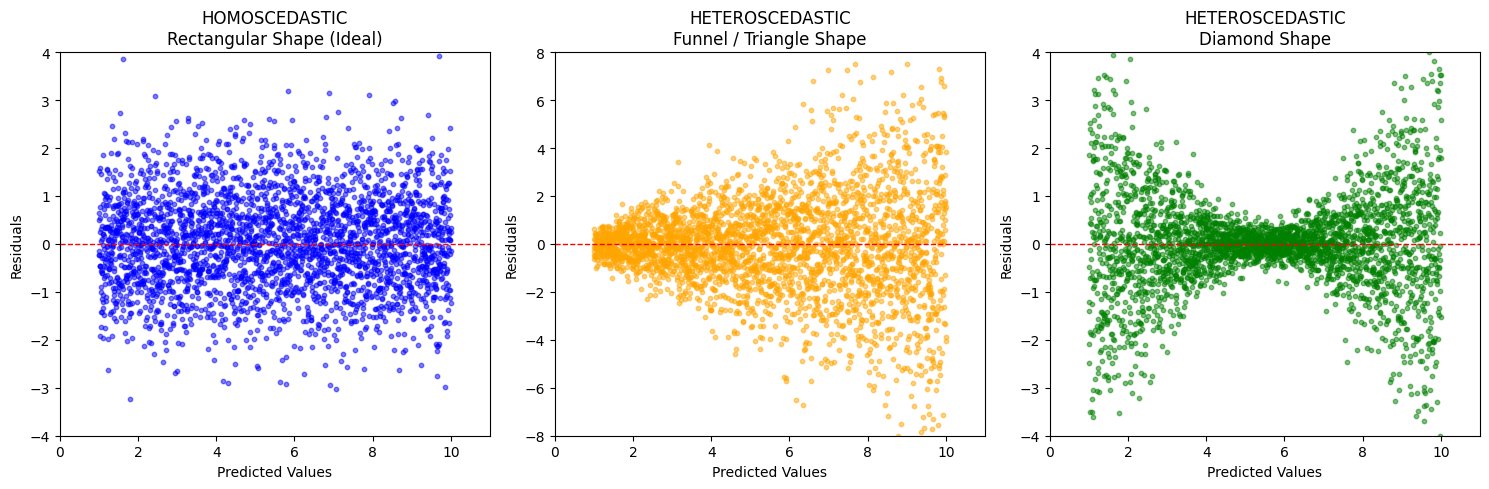


=== Reference Patterns for Residuals vs Predicted Plot ===

1. RECTANGULAR SHAPE (Left plot):
   - Constant width of points across all predicted values
   - Random scatter around zero line
   - Indicates HOMOSCEDASTICITY (ideal)

2. FUNNEL / TRIANGLE SHAPE (Middle plot):
   - Spread widens (or narrows) as predicted values increase
   - Forms a cone or triangle shape
   - Indicates HETEROSCEDASTICITY (violation)

3. DIAMOND SHAPE (Right plot):
   - Spread narrow in the middle, widens at both ends
   - Forms a diamond pattern
   - Indicates HETEROSCEDASTICITY (violation)



In [56]:
# reference_homoscedasticity.py

import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n = 3000
x = np.linspace(1, 10, n)

# 1. HOMOSCEDASTIC (Rectangular shape)
# Constant variance across all predicted values
predicted_homo = x
residuals_homo = np.random.normal(0, 1, n)  # Constant standard deviation = 1

# 2. HETEROSCEDASTIC - FUNNEL (Triangle/Cone shape)
# Variance increases with predicted values
residuals_funnel = np.random.normal(0, x / 3, n)  # Standard deviation grows with x

# 3. HETEROSCEDASTIC - DIAMOND shape
# Variance low in middle, high at ends
variance_diamond = (x - np.mean(x)) ** 2 / 10
residuals_diamond = np.random.normal(0, variance_diamond + 0.2, n)

# Create the reference plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Homoscedastic (Rectangular)
axes[0].scatter(predicted_homo, residuals_homo, alpha=0.5, s=10, color='blue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('HOMOSCEDASTIC\nRectangular Shape (Ideal)')
axes[0].set_xlim(0, 11)
axes[0].set_ylim(-4, 4)

# Plot 2: Funnel (Triangle/Cone)
axes[1].scatter(predicted_homo, residuals_funnel, alpha=0.5, s=10, color='orange')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('HETEROSCEDASTIC\nFunnel / Triangle Shape')
axes[1].set_xlim(0, 11)
axes[1].set_ylim(-8, 8)

# Plot 3: Diamond
axes[2].scatter(predicted_homo, residuals_diamond, alpha=0.5, s=10, color='green')
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Predicted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('HETEROSCEDASTIC\nDiamond Shape')
axes[2].set_xlim(0, 11)
axes[2].set_ylim(-4, 4)

plt.tight_layout()
plt.show()

# Print description
print("\n=== Reference Patterns for Residuals vs Predicted Plot ===\n")
print("1. RECTANGULAR SHAPE (Left plot):")
print("   - Constant width of points across all predicted values")
print("   - Random scatter around zero line")
print("   - Indicates HOMOSCEDASTICITY (ideal)\n")

print("2. FUNNEL / TRIANGLE SHAPE (Middle plot):")
print("   - Spread widens (or narrows) as predicted values increase")
print("   - Forms a cone or triangle shape")
print("   - Indicates HETEROSCEDASTICITY (violation)\n")

print("3. DIAMOND SHAPE (Right plot):")
print("   - Spread narrow in the middle, widens at both ends")
print("   - Forms a diamond pattern")
print("   - Indicates HETEROSCEDASTICITY (violation)\n")

# Reference patterns for Q-Q plots

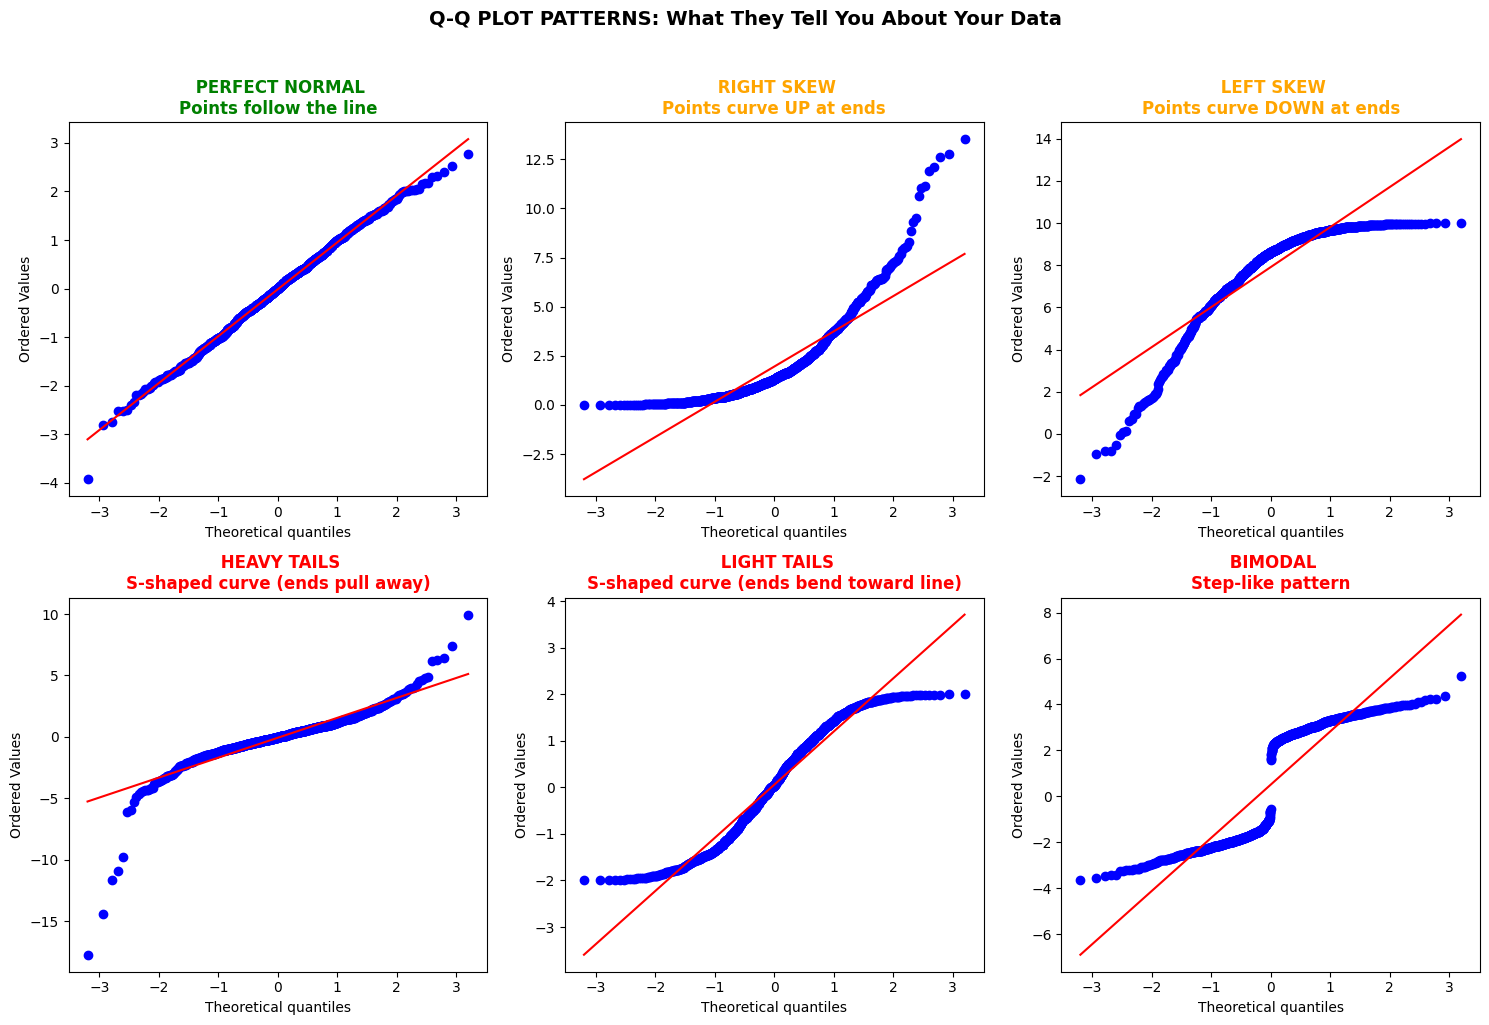

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Perfect Normal
normal_data = np.random.normal(0, 1, 1000)
stats.probplot(normal_data, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title(' PERFECT NORMAL\nPoints follow the line', fontweight='bold', color='green')

# 2. Right Skew (Long right tail)
right_skew = np.random.exponential(2, 1000)
stats.probplot(right_skew, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title(' RIGHT SKEW\nPoints curve UP at ends', fontweight='bold', color='orange')

# 3. Left Skew (Long left tail)
left_skew = -np.random.exponential(2, 1000) + 10
stats.probplot(left_skew, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title(' LEFT SKEW\nPoints curve DOWN at ends', fontweight='bold', color='orange')

# 4. Heavy Tails (More extreme values than normal)
heavy_tails = np.random.standard_t(df=3, size=1000)  # t-distribution with heavy tails
stats.probplot(heavy_tails, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title(' HEAVY TAILS\nS-shaped curve (ends pull away)', fontweight='bold', color='red')

# 5. Light Tails (Fewer extreme values than normal)
light_tails = np.random.uniform(-2, 2, 1000)  # Uniform distribution (no tails)
stats.probplot(light_tails, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title(' LIGHT TAILS\nS-shaped curve (ends bend toward line)', fontweight='bold', color='red')

# 6. Bimodal (Two peaks)
bimodal = np.concatenate([np.random.normal(-2, 0.5, 500), np.random.normal(3, 0.5, 500)])
stats.probplot(bimodal, dist="norm", plot=axes[1, 2])
axes[1, 2].set_title(' BIMODAL\nStep-like pattern', fontweight='bold', color='red')

plt.suptitle('Q-Q PLOT PATTERNS: What They Tell You About Your Data',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()